# Imports

In [826]:
# Imports and setup
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor 
from xgboost import XGBRegressor

from sklearn.feature_selection import mutual_info_regression 
from sklearn.feature_selection import f_regression

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder


import category_encoders as ce

from datetime import datetime
import time
from IPython.display import display, HTML

from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy import stats

import os
import itables
from itables import show

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Constants

In [121]:
# Some useful constants
TARGET_COL = "SalePrice"
LOGP_TARGET_COL = f"{TARGET_COL}_log1p"
RANDOM_STATE = 0
TEST_PORCENT = 0.2  # Proportion of the dataset to include in the test split
MAX_OHE_CARDINALITY = 18  # Maximum unique values for one-hot encoding

g_df_scores = pd.DataFrame() #  DataFrame to store scores
g_run_id = 0  # Global run id to use in scores


# Columns

In [673]:
# Ordinal Columns
# OverallCond and OverallQuall are ordinal but no process is necessary
ORD_COLS = [
    "LandSlope", "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"
]

ORD_COLS_VALUES = { 
    "LandSlope": {"Gtl": 1, "Mod": 2, "Sev": 3},
    "ExterQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "ExterCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtQual": {"Ex": 10, "Gd": 9, "TA": 8, "Fa": 7, "Po": 3, "NA": 0},
    "BsmtCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtExposure": {"Gd": 5, "Av": 4, "Mn": 3, "No": 2, "NA": 0},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, 
                     'NA':0},
    'BsmtFinType2': {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':0},
    'HeatingQC':{'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1},
    'FireplaceQu':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageQual':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageCond':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'PoolQC' : {'Ex' :10 , 'Gd' :9 , 'TA' :8 , 'Fa' :7 , 'Po' :3 , 'NA' :0}
}

# Functions

## Print Info Functions

In [123]:
def print_null_count(df, col_name):
    """
    Print the number of null values in a specific column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to check.
    col_name (str): The name of the column to check for null values.
    """
    print(f"Column '{col_name}' has {df[col_name].isnull().sum()} null values.")

def println(ch="-", n=30):
  print(ch * n)

def printspace():
  println(ch=" ")

def show_global_scores():
    global g_df_scores
    display(g_df_scores)


## Plot functions

In [124]:
def compute_fig_matrix_size(features):
  plot_count = len(features)
  if plot_count == 0:
    return
    
  # Show 'num_cols' plots per row
  col_count = min(plot_count, 3)
  row_count = plot_count // col_count
  row_count += 0 if (plot_count % col_count) == 0 else 1
  
  return row_count, col_count

### Show Histograms

In [125]:

def show_histogram(data, features):
  build_bar_plot(data, features, ptype="histogram")
  
def show_bar_plot(data, features):
  build_bar_plot(data, features, ptype="bar")

def build_bar_plot(data, features, ptype="bar"):
    if type(features) is not list:
        features = [features]

    row_count, num_cols = compute_fig_matrix_size(features)
    # Create subplots
    fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(10, 10), squeeze=False)
    fig.tight_layout(pad=2.0)

    curr_row = 0
    curr_col = 0
    for feat_idx, feat_name in enumerate(features):
        curr_row = feat_idx // num_cols
        ax = axes[curr_row, curr_col]
        if ptype == "histogram":
          ax.hist(data[feat_name], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        elif ptype == "bar":
          categories = data[feat_name].unique()
          counts =  data[feat_name].value_counts()
          #print("Categories for", feat_name, ":", categories)
          #print("counts for", feat_name, ":", counts)
          ax.bar(categories, counts) 
        ax.set_title("")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Frequency") 
        if curr_col == num_cols - 1:
            curr_col = 0
        else:
            curr_col += 1

    # Show plot
    plt.show()

### Show Distribution

In [126]:
def show_distribution(data, features):
    if type(features) is not list:
        features = [features]
    
    plot_count = len(features)
    if plot_count == 0:
        return

    
    # Show 'num_cols' plots per row
    num_cols = min(plot_count, 3)
    row_count = plot_count // num_cols
    row_count += 0 if (plot_count % num_cols) == 0 else 1
    # Create subplots
    fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(10, 5), squeeze=False)
    fig.tight_layout(pad=2.0)

    curr_row = 0
    curr_col = 0
    for feat_idx, feat_name in enumerate(features):
        kde = gaussian_kde(data[feat_name])
        mu, sigma = np.mean(data[feat_name]), np.std(data[feat_name])
        x_vals = np.linspace(data[feat_name].min(), data[feat_name].max(), 200)
        
        curr_row = feat_idx // num_cols
        ax = axes[curr_row, curr_col]
        ax.plot(x_vals, kde(x_vals), color="red", lw=2)
        ax.plot(x_vals, norm.pdf(x_vals, mu, sigma), color="yellow", lw=2)
        ax.hist(data[feat_name], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        #ax.set_title(f"Distribution for {feat_name}")
        ax.set_title("")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Frequency") 
        if curr_col == num_cols - 1:
            curr_col = 0
        else:
            curr_col += 1

    # Show plot
    plt.show()

### Show Q-Q Plot

In [127]:
def show_qq_plot(df, features):
  if type(features) is not list:
    features = [features]
    
  plot_count = len(features)
  if plot_count == 0:
    return

  # Show 'num_cols' plots per row
  num_cols = min(plot_count, 3)
  row_count = plot_count // num_cols
  row_count += (0 if plot_count % num_cols == 0 else 1)
  print("Row count", row_count)
  # Create subplots
  curr_row = 0
  curr_col = 0
  fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(7, 5), squeeze=False)
  fig.tight_layout(pad=2.0)
  for i, f in enumerate(features):
    curr_row = i // num_cols
    ax = axes[curr_row, curr_col]
    stats.probplot(df[f], dist="norm", plot=ax)
    ax.set_ylabel(f)
    ax.set_xlabel("q") 
    ax.set_title(f"Q-Q Plot for {f}")
    if curr_col == num_cols - 1:
      curr_col = 0
    else:
      curr_col += 1
  plt.show()

### Scores

In [212]:
def clear_global_scores():
  global g_df_scores
  global g_run_id
  g_run_id = 0
  g_df_scores = pd.DataFrame()

def mark_failed_score(run_id):
  g_df_scores.loc[g_df_scores["run_id"] == run_id, "failed"] = True

SHOW_ALL="all"
SHOW_LAST_10="last_10"
SHOW_LABEL="label"
SHOW_BEST_5="best_5"
def plot_scores(show_test=False, show=SHOW_LAST_10, label=""):

  df = g_df_scores.copy()

  if show == SHOW_LAST_10:
    df = df.tail(10)
  elif show == SHOW_LABEL:
    df = df[df["run_label"] == label]
  elif show == SHOW_BEST_5:
    df = df.sort_values(by="CV_MEAN").tail(5)
    
  # Combine model + run label for easier plotting
  df["model_run"] = df["model"].astype(str) + "\n(" + df["run_label"].astype(str) + ")"

  # Assign a unique color per model
  unique_models = df["model"].unique()
  colors = plt.cm.tab10(range(len(unique_models)))  # 10 distinct colors
  color_map = dict(zip(unique_models, colors))

  # Map the colors to each row
  df["color"] = df["model"].map(color_map)

  # Set figure and subplots
  splot_count = 2
  if show_test:
    splot_count = 3

  fig, axes = plt.subplots(splot_count, 1, figsize=(14, 5))

  axnum = 0
  # --- Bar chart for Train RMSE ---
  bars = axes[axnum].bar(df["model_run"], df["TRN_RMSE"], color=df["color"])
  axes[axnum].set_title("Train set (RMSE)")
  axes[axnum].set_ylabel("RMSE")
  axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)   

  if show_test:
    axnum += 1
    # --- Bar chart for Test RMSE ---
    bars = axes[axnum].bar(df["model_run"], df["TST_RMSE"], color=df["color"])
    axes[axnum].set_title("Test set (RMSE)")
    axes[axnum].set_ylabel("RMSE")
    axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)

  # --- Bar chart for CV_MEAN ---
  axnum += 1
  bars = axes[axnum].bar(df["model_run"], df["CV_MEAN"], color=df["color"])
  axes[axnum].set_title("Cross validation (CV_MEAN)")
  axes[axnum].set_ylabel("CV_MEAN")
  axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)

  plt.tight_layout()
  plt.show() 

### Show Scores Stats

In [699]:
def show_run_desc(run_id, model):
    df = g_df_scores[g_df_scores["run_id"] == run_id]
    df = df[df["model"] == model]
    df = df.iloc[0]
    print("RunId:", f"{run_id} ({df["run_label"]}) - model:", df["model"], ("[Failed]" if df["failed"] else ""))
    print("Score:", nfmt(df["CV_MEAN"]), "- TRN_RMSE:", nfmt(df["TRN_RMSE"]))
    print("Description:")
    print(g_df_scores[g_df_scores["run_id"] == run_id]["DESC"]) 

#show_run_desc(103, "Rig")

In [788]:
def show_scores_stats(by_label_list=False, process_time=False, by_model_desc=False):
  global g_df_scores
  curr_validation_tag = "KFolds+cross_val_score"
  df_base = g_df_scores[g_df_scores["failed"] == False].copy()
  # Adding filter to display values after changing cross val split
  df_base = df_base[df_base["validation_tag"] == curr_validation_tag]
  df_last = df_base[df_base["run_id"] == df_base["run_id"].max()]
  println()

  """
   Display last experiment run data
  """
  print("Last Run:", df_last["run_id"].iloc[0], "-", df_last["run_label"].iloc[0])
  println()
  for i, row in df_last.iterrows():
    print("Model:", row["model"],"CV_MEAN:", nfmt(row["CV_MEAN"]), "TRN_RMSE:", nfmt(row["TRN_RMSE"]))
  print("Description:", df_last["DESC"].iloc[0])

  """
    Display average by Run Label
  """
  if by_label_list:
    df = df_base.groupby("run_label")
    println()
    print("Score Stats")
    println()
    for name, group in df:
      print("Name:", name)
      print("Avg Tr:", nfmt(group["TRN_RMSE"].mean()))
      print("Avg CV:", nfmt(group["CV_MEAN"].mean()))
      df_grp_best = group[group["CV_MEAN"] == group["CV_MEAN"].min()].iloc[0]

      proc_time = ""
      if process_time:
        proc_time = "Proc.Time:" + nfmt(df_grp_best["EVAL_TIME_SEC"]) + "secs"

      """
       Best by Run Label detail
      """
      print("Best(CV):", f"[{df_grp_best['run_label']}]", f"({df_grp_best['run_id']})", df_grp_best["model"], \
            "--> Score:", nfmt(df_grp_best["CV_MEAN"]), proc_time)
      print("Description:")
      print(df_grp_best["DESC"])
      printspace()

  """
   Display Top  5 run performances 
  """
  
  rank = df_base.copy().sort_values(by="CV_MEAN", ascending=True).reset_index(drop=True)
  rank["delta"] = rank["CV_MEAN"] - rank["CV_MEAN"].shift(1)
  println()
  print("Top 5")
  println()
  for i, row in rank[:5].iterrows():
    proc_time = ""
    if process_time:
      proc_time = f"Proc.Time: {nfmt(row['EVAL_TIME_SEC'])} secs"
    print(f"{row['run_label']}({row['run_id']}) - {row['model']} --> CV_MEAN: {nfmt(row['CV_MEAN'])}, delta: {nfmt(row['delta'])}", proc_time)

  printspace()
  println()
  
  # Global Best detail
  gdf = df_base.copy()
  df_best = gdf[gdf["CV_MEAN"] == gdf["CV_MEAN"].min()].iloc[0]
  print("Global Best(CV): ", f"[{df_best['run_label']}]", f"({df_best['run_id']})", df_best["model"], \
        "--> Score:", nfmt(df_best["CV_MEAN"]))
  if process_time:
    print("Process time:", nfmt(df_best["EVAL_TIME_SEC"]), "sec")
  print("Description:")
  print(df_best["DESC"])

  # Top five by Run Id. Average of CV_MEAN
  df = df_base.groupby("run_id").agg({"CV_MEAN": "mean", "TRN_RMSE": "mean"}).sort_values(by="CV_MEAN", ascending=True)
  println()
  print("Top 5 Mean by run_id")
  println()
  for run_id, group in df[:5].iterrows():
    print(f"{run_id} --> CV_MEAN: {nfmt(group['CV_MEAN'])}, TRN_RMSE: {nfmt(group['TRN_RMSE'])}")
  printspace()
  println()
  if df.shape[0] > 0:
    run_id = df.iloc[0].name
    df = df_base[df_base["run_id"] == run_id]
    #  Global Best by Run Id detail
    print("Best AVG CV: ", f"({run_id}) --> Score:", nfmt(df["CV_MEAN"].mean()), "- TRN_RMSE:", nfmt(df["TRN_RMSE"].mean()))
    print("Description:")
    print(g_df_scores[g_df_scores["run_id"] == run_id].iloc[0]["DESC"]) 

  # Best by model list
  df_model = df_base.groupby("model")

  print("Best by Model")
  println()
  for model, group in df_model:
    df_best = group[group["CV_MEAN"] == group["CV_MEAN"].min()].iloc[0]
    print(model, "Run Id:", df_best["run_id"], f"({df_best["run_label"]}) -> CV_MEAN:", nfmt(df_best["CV_MEAN"]), \
          "TRN_RMSE:", nfmt(df_best["TRN_RMSE"]))
    if by_model_desc:
      print("Description:")
      print(df_best["DESC"])





    
#show_scores_stats()

### Show Target Pairplot

In [130]:
def show_target_pairplot(df, features, target):
  if type(features) is not list:
    features = [features]
    
  plot_count = len(features)
  if plot_count == 0:
    return

  # Show 'num_cols' plots per row
  num_cols = min(plot_count, 3)
  row_count = plot_count // num_cols
  row_count += (0 if plot_count % num_cols == 0 else 1)
  # Create subplots
  curr_row = 0
  curr_col = 0
  fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(9, 9), squeeze=False)
  fig.tight_layout(pad=2.0)
  for i, f in enumerate(features):
    curr_row = i // num_cols
    ax = axes[curr_row, curr_col]
    ax.plot(df[f], df[target], ".")
    ax.set_ylabel(target)
    ax.set_xlabel(f) 
    #ax.set_title(f"Pair Plot {f} - {target}") // Consumes spaces
    if curr_col == num_cols - 1:
      curr_col = 0
    else:
      curr_col += 1
  plt.show()

## Metrics Functions

In [254]:
# Metric functions 
def compute_rmse(y, y_pred):
  """Compute Root Mean Squared Error (RMSE)"""
  return root_mean_squared_error(y, y_pred)    
        
def compute_nrmse(y, y_pred):
  """Computes Normalized Root Mean Squared Error (NRMSE)"""
  rmse = compute_rmse(y, y_pred)
  return rmse / np.mean(y) 
    
def compute_perc_nrmse(y, y_pred):
  return compute_nrmse(y, y_pred) * 100

def compute_metrics(y, y_pred):
  result = {}
  result["RMSE"] = compute_rmse(y, y_pred)
  result["NRMSE"] = compute_nrmse(y, y_pred)
  result["PERC_NRMSE"] = compute_perc_nrmse(y, y_pred)
  return result

def mean(vals):
  return vals.mean() if len(vals) > 0 else 0


## Eval functions

### Models Config

In [132]:
def get_models():
    return [
        {
          "name": "Linear Regression",
          "abrev": "LiRe",
          "instance": LinearRegression(),
        },
        {
          "name": "Decision Tree Regressor",
          "abrev": "TrRe",
          "instance": DecisionTreeRegressor(),
        },
        {
          "name": "Ridge",
          "abrev": "Rig",
          "instance": Ridge(alpha=0.7),
        },
        {
          "name": "XGBRegressor",
          "abrev": "XBReg",
          "instance": XGBRegressor(),
        },
    ]


### Evaluation

In [763]:
def rndnum(n):
    return round(n, 5)
    
def clear_scores():
    global g_df_scores
    g_df_scores = pd.DataFrame()

def standard_neg_rmse_scorer(estimator, X, y):
    return -1 * compute_rmse(y, estimator.predict(X))
  
def standard_rmse_scorer(estimator, X, y):
    return compute_rmse(y, estimator.predict(X))

# Evaluation functions
def eval_model(model, X, Y, X_test, Y_test, label="no_label", desc="", pred_test=False, run_id=0, show_model_params=False, save_score=True):
    """
    Evaluates a regression model using cross-validation and prints the RMSE and NRMSE.
    
    Args:
        model: The regression model to evaluate.
        X (pd.DataFrame): Features for training.
        Y (pd.Series): Target variable for training.
        X_test (pd.DataFrame): Features for testing.
        Y_test (pd.Series): Target variable for testing.
        cross_val (bool): Whether to perform cross-validation. Default is False.
    """
    global g_df_scores
    start_time = time.time()

    scorer = standard_rmse_scorer
    cv = KFold(
      n_splits=5,
      shuffle=True,
      random_state=RANDOM_STATE
    ) 
    scores = cross_val_score(model["instance"], X, Y, cv=cv, scoring=scorer)

    model_inst = model["instance"]
    model_inst.fit(X, Y)

    if show_model_params:
      print(f"Model: {model["name"]},  Params: {model_inst.get_params()}")
    pred_train = model_inst.predict(X)
    result = compute_metrics(Y, pred_train)

    result_test = None
    if pred_test:
        pred_test = model_inst.predict(X_test)
        result_test = compute_metrics(Y_test, pred_test)

    if not save_score:
      print("Model:", model["name"])
      print("Cross val scores:", scores)
      print("Train score:", result)
      print("Score not saved")
      return

    print("Saving score in memory")
    eval_time = time.time() - start_time
    new_row = {
        "run_id": run_id,
        "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "model": model["abrev"],
        "run_label": label,
        "TRN_RMSE": rndnum(result["RMSE"]),
        "TRN_NRMSE": rndnum(result["NRMSE"]),
        "TRN_PERC_NRMSE": rndnum(result["PERC_NRMSE"]),
        "TST_RMSE": rndnum(0 if result_test is None else result_test["RMSE"]),
        "TST_NRMSE": rndnum(0 if result_test is None else result_test["NRMSE"]),
        "TST_PERC_NRMSE": rndnum(0 if result_test is None else result_test["PERC_NRMSE"]),
        "CV_MEAN": rndnum(mean(scores)),
        "CV_STD": rndnum(std(scores)),
        "CV_01": rndnum(scores[0]),
        "CV_02": rndnum(scores[1]),
        "CV_03": rndnum(scores[2]),
        "CV_04": rndnum(scores[3]),
        "CV_05": rndnum(scores[4]),
        "DESC": desc,
        "EVAL_TIME_SEC": eval_time,
        "failed": False, # Used to mark when something wrong discovered in evaluation
        "validation_tag": "KFolds+cross_val_score", 
    }

    df_new_row = pd.DataFrame([new_row])
    if g_df_scores.shape[0] == 0:
        g_df_scores = df_new_row
    else:
        g_df_scores = pd.concat([g_df_scores, df_new_row], ignore_index=True)

def eval_models(X, Y, X_test, Y_test, label="run_label", models=None, clear_scores=False, desc="", show_model_params=False, save_score=True): 
    global g_run_id
    clear = clear_scores
    ev_models = models
    if ev_models is None:
        ev_models = get_models()
    if clear_scores:
        clear_global_scores()
    
    g_run_id+=1
    for model in ev_models:
        eval_model(model, X, Y, X_test, Y_test, label=run_label, run_id=g_run_id, desc=desc, show_model_params=show_model_params, save_score=save_score)

    if (g_run_id  % 5) == 0:
      save_scores(g_df_scores)

## Helpers

# Load Data

In [134]:
# Loading data and split datasets
#df_submit = pd.read_csv("./data/test.csv")
df_raw_data = pd.read_csv("./data/train.csv")
df_data = df_raw_data.copy()

In [628]:
def nfmt(n):
    """Format number to 4 decimal places"""
    return f"{n:,.4f}" if n is not None else "None"
  
def pfmt(n):
    """Format number for porcentage"""
    return f"{(n*100):.2f}%" if n is not None else "None"

def save_scores(df=g_df_scores, file_prefix="scores", folder="score_data"):
  # Step 1: Get current date in YYMMDD format
  date_str = datetime.now().strftime("%y%m%d")
  filename = f"./{folder}/{file_prefix}_{date_str}.csv"
  
  # Step 2: Check if file exists
  file_exists = os.path.isfile(filename)
  
  # Step 3: Save or append data
  df.to_csv(
      filename,
      mode='a' if file_exists else 'w',
      header=not file_exists,
      index=False
  )
  print("Saved scores to file:", filename)

def this_year():
  return datetime.now().year

# EDA

## General data exploration

In [136]:
df_data.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [137]:
df_types = pd.DataFrame(df_data.dtypes, columns=["dType"])
df_types["dType"] = df_types["dType"].astype(str)
df_types.sort_values(by="dType")

,dType
LotFrontage,float64
MasVnrArea,float64
GarageYrBlt,float64
Id,int64
BsmtUnfSF,int64
TotalBsmtSF,int64
1stFlrSF,int64
2ndFlrSF,int64
LowQualFinSF,int64
GrLivArea,int64


In [138]:
def show_columns_by_type():
  df_gtypes = df_types.groupby("dType")
  for g, c in df_gtypes:
    print(g)
    println()
    print(c.index.tolist())
    printspace()
  
show_columns_by_type()

float64
------------------------------
['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
                              
int64
------------------------------
['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
                              
str
------------------------------
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'Bsmt

## Checking Null values

In [139]:

null_cols = df_data.columns[df_data.isnull().sum() > 0]
print("Total Rows", len(df_data))
df_data[null_cols].info()

Total Rows 1460
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotFrontage   1201 non-null   float64
 1   Alley         91 non-null     str    
 2   MasVnrType    588 non-null    str    
 3   MasVnrArea    1452 non-null   float64
 4   BsmtQual      1423 non-null   str    
 5   BsmtCond      1423 non-null   str    
 6   BsmtExposure  1422 non-null   str    
 7   BsmtFinType1  1423 non-null   str    
 8   BsmtFinType2  1422 non-null   str    
 9   Electrical    1459 non-null   str    
 10  FireplaceQu   770 non-null    str    
 11  GarageType    1379 non-null   str    
 12  GarageYrBlt   1379 non-null   float64
 13  GarageFinish  1379 non-null   str    
 14  GarageQual    1379 non-null   str    
 15  GarageCond    1379 non-null   str    
 16  PoolQC        7 non-null      str    
 17  Fence         281 non-null    str    
 18  MiscFeature   54 non-nu

In [140]:

# Cell used to analyze null column values to fix in the cell below
null_field = "Fence"
#print("unique: ", df_data[df_data[null_field].notnull()][null_field].unique())
print_null_count(df_data, null_field)
#df_data[df_data[null_field].isnull()][null_field]
print("Mode for ", null_field, "is:", df_data[null_field].mode()[0])
df_data[df_data.columns[df_data.isnull().sum() > 0]].head(15)
df_data["Fence"].value_counts()
#print("cnt:", len(df_data.query('PoolQC.isnull() and PoolArea != 0')))

Column 'Fence' has 1179 null values.
Mode for  Fence is: MnPrv


Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

## Fixing null cols

Trying to fill null values based on documentation and data analysis examining each column individually.<BR>
Fixing columns in EDA to be able to check distribution on features

In [141]:
def fix_nulls(df):
  print("Total null columns Before:", len(df.columns[df.isnull().sum() > 0]))
  # Let's apply "None" to all nans
  df["MiscFeature"] = df["MiscFeature"].fillna("None")
  
  df[df["LotFrontage"].isnull()]["LotFrontage"]
  # Let's set to the mean to lotFrontage
  df["LotFrontage"] = df["LotFrontage"].fillna(df[df["LotFrontage"].notnull()]["LotFrontage"].mean())
  
  # Setting "None" to Alley
  df["Alley"] = df["Alley"].fillna("None")
  
  # Setting "None" to MasVnrType (Masonry Veneer Type)
  df["MasVnrType"] = df["MasVnrType"].fillna("None")
  
  # Setting "0" to MasVnrArea (Masonry Veneer Area)
  df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
  
  # Setting NA to BsmtQual for null values (Based on documentation) 
  df["BsmtQual"] = df["BsmtQual"].fillna("NA")
  df["BsmtCond"] = df["BsmtCond"].fillna("NA")
  df["BsmtExposure"] = df["BsmtExposure"].fillna("NA")
  df["BsmtFinType1"] = df["BsmtFinType1"].fillna("NA")
  df["BsmtFinType2"] = df["BsmtFinType2"].fillna("NA")
  
  # Electrical column has 1 null value, let's set it to "SBrkr" (mode)
  df["Electrical"] = df["Electrical"].fillna("SBrkr")
  
  
  # FireplaceQu is null for all rows having Fireplaces == 0. Let's set it to "NA" 
  df["FireplaceQu"] = df["FireplaceQu"].fillna("NA")
  
  # GarageType, Finish, Qual and Cond and GarageYrBlt is null for all rows having GarageCars == 0. Let's set it to "NA" and 0 respectibly
  df["GarageType"] = df["GarageType"].fillna("NA")
  df["GarageFinish"] = df["GarageFinish"].fillna("NA")
  df["GarageQual"] = df["GarageQual"].fillna("NA")
  df["GarageCond"] = df["GarageCond"].fillna("NA")
  
  # and GarageYrBlt is null for all rows having GarageCars == 0. Let's set it to "NA" and 0 respectibly
  df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
  
  # PoolQC is null for all rows having PoolArea == 0. Let's set it to "NA" 
  df["PoolQC"] = df["PoolQC"].fillna("NA")
  
  # Assumming that null Fence values means NA
  df["Fence"] = df["Fence"].fillna("NA")
  print("Total null columns After:", len(df.columns[df.isnull().sum() > 0]))
  return df

# Printing null values to check if all nulls are fixed
# for col in df.columns:
#   print_null_count(df, col)

# Counting columns having null values

df_data = fix_nulls(df_data)
df_data[null_cols].head(5)

Total null columns Before: 19
Total null columns After: 0


,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,None,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NA,Attchd,2003.0,RFn,TA,TA,NA,NA,None
1,80.0,None,None,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NA,NA,None
2,68.0,None,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NA,NA,None
3,60.0,None,None,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NA,NA,None
4,84.0,None,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NA,NA,None


## Target data analysis

In [142]:
# Checking values to see what the target is about
df_data[TARGET_COL].describe()

# Observations
# There is a wide range of values
# Median < Mean => Right skewed distribution



count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice_log1p, dtype: float64


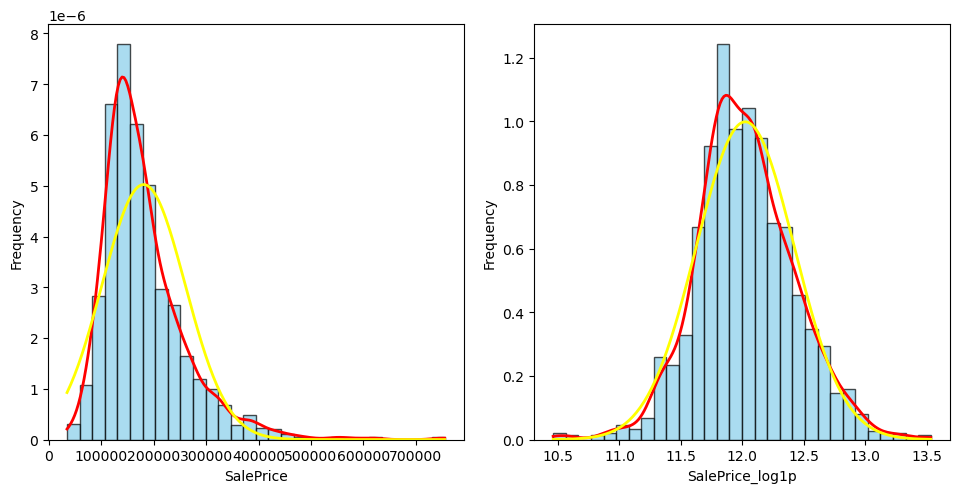

In [143]:
# Plotting distribution
df_data[LOGP_TARGET_COL] = np.log1p(df_data[TARGET_COL])
print(df_data[LOGP_TARGET_COL].describe())
show_distribution(df_data, [TARGET_COL, LOGP_TARGET_COL])
# Distribution is clearly right skewed
# When applying log1p transformation, the distribution becomes more normal
# log1p => Mean ~= Median


Row count 1


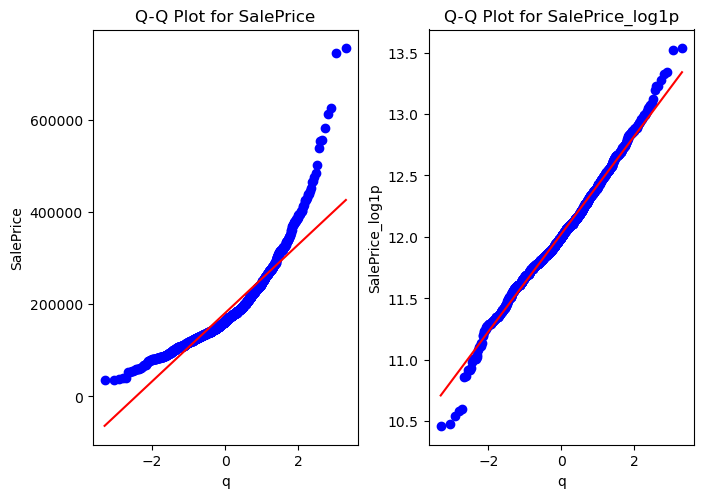

In [144]:
# Q-Q plot to check when the model will struggle
show_qq_plot(df_data, [TARGET_COL, LOGP_TARGET_COL])

# Observations
# 1. Log1p has some outliers, but distribution is more normal

In [145]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               1460 non-null   int64  
 1   MSSubClass       1460 non-null   int64  
 2   MSZoning         1460 non-null   str    
 3   LotFrontage      1460 non-null   float64
 4   LotArea          1460 non-null   int64  
 5   Street           1460 non-null   str    
 6   Alley            1460 non-null   str    
 7   LotShape         1460 non-null   str    
 8   LandContour      1460 non-null   str    
 9   Utilities        1460 non-null   str    
 10  LotConfig        1460 non-null   str    
 11  LandSlope        1460 non-null   str    
 12  Neighborhood     1460 non-null   str    
 13  Condition1       1460 non-null   str    
 14  Condition2       1460 non-null   str    
 15  BldgType         1460 non-null   str    
 16  HouseStyle       1460 non-null   str    
 17  OverallQual      1460 non

In [146]:
# Dropping Id column as it is not needed for training
df_data = df_data.drop(columns=["Id"], errors='ignore')


## Correlation with Target

In [147]:

# Checking positive and negative correlation. Graving more positive values because there are more positive correlations than negative ones.
print(TARGET_COL)
println()
df_corr = df_data.corr(numeric_only=True)[np.abs(df_data.corr(numeric_only=True)[TARGET_COL].values) > 0.5].sort_values(by=TARGET_COL, ascending=False)
print(df_corr[TARGET_COL])
printspace()
print(LOGP_TARGET_COL)
println()
df_corr_logp = df_data.corr(numeric_only=True)[np.abs(df_data.corr(numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
print(df_corr_logp[LOGP_TARGET_COL])
#print(df_corr.shape)

SalePrice
------------------------------
SalePrice          1.000000
SalePrice_log1p    0.948374
OverallQual        0.790982
GrLivArea          0.708624
GarageCars         0.640409
GarageArea         0.623431
TotalBsmtSF        0.613581
1stFlrSF           0.605852
FullBath           0.560664
TotRmsAbvGrd       0.533723
YearBuilt          0.522897
YearRemodAdd       0.507101
Name: SalePrice, dtype: float64
                              
SalePrice_log1p
------------------------------
SalePrice_log1p    1.000000
SalePrice          0.948374
OverallQual        0.817185
GrLivArea          0.700927
GarageCars         0.680625
GarageArea         0.650888
TotalBsmtSF        0.612134
1stFlrSF           0.596981
FullBath           0.594771
YearBuilt          0.586570
YearRemodAdd       0.565608
TotRmsAbvGrd       0.534422
Name: SalePrice_log1p, dtype: float64


In [148]:
df_corr_logp[df_corr_logp.index]

,SalePrice_log1p,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,TotRmsAbvGrd
SalePrice_log1p,1.000000,0.948374,0.817185,0.700927,0.680625,0.650888,0.612134,0.596981,0.594771,0.586570,0.565608,0.534422
SalePrice,0.948374,1.000000,0.790982,0.708624,0.640409,0.623431,0.613581,0.605852,0.560664,0.522897,0.507101,0.533723
OverallQual,0.817185,0.790982,1.000000,0.593007,0.600671,0.562022,0.537808,0.476224,0.550600,0.572323,0.550684,0.427452
GrLivArea,0.700927,0.708624,0.593007,1.000000,0.467247,0.468997,0.454868,0.566024,0.630012,0.199010,0.287389,0.825489
GarageCars,0.680625,0.640409,0.600671,0.467247,1.000000,0.882475,0.434585,0.439317,0.469672,0.537850,0.420622,0.362289
GarageArea,0.650888,0.623431,0.562022,0.468997,0.882475,1.000000,0.486665,0.489782,0.405656,0.478954,0.371600,0.337822
TotalBsmtSF,0.612134,0.613581,0.537808,0.454868,0.434585,0.486665,1.000000,0.819530,0.323722,0.391452,0.291066,0.285573
1stFlrSF,0.596981,0.605852,0.476224,0.566024,0.439317,0.489782,0.819530,1.000000,0.380637,0.281986,0.240379,0.409516
FullBath,0.594771,0.560664,0.550600,0.630012,0.469672,0.405656,0.323722,0.380637,1.000000,0.468271,0.439046,0.554784
YearBuilt,0.586570,0.522897,0.572323,0.199010,0.537850,0.478954,0.391452,0.281986,0.468271,1.000000,0.592855,0.095589


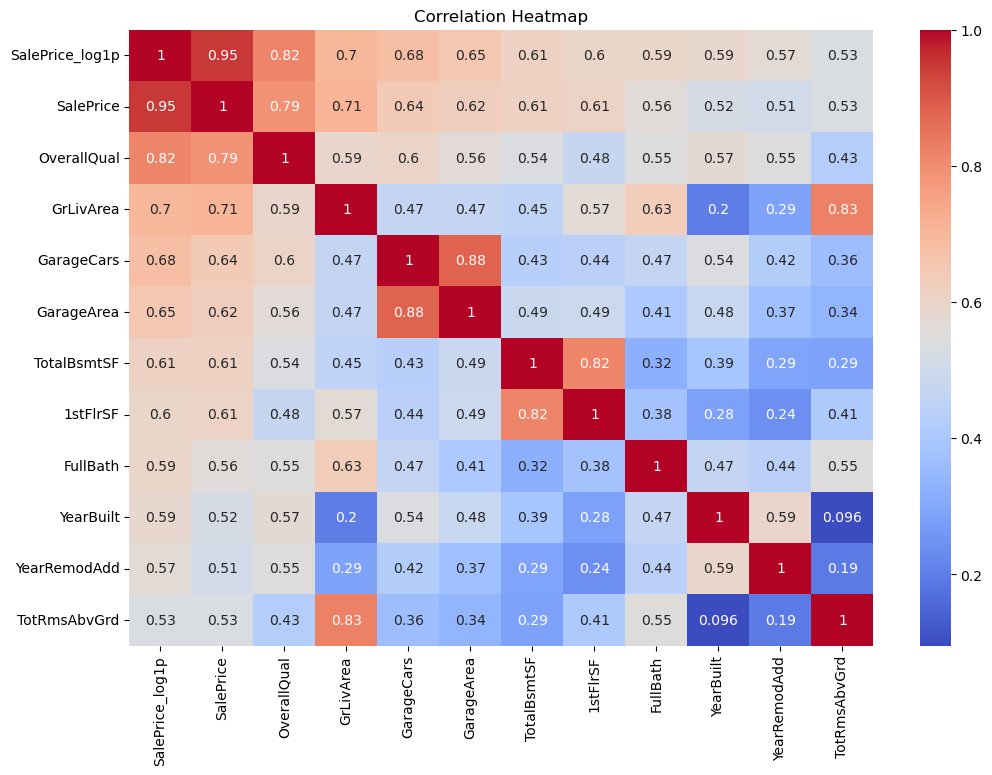

In [149]:
# Let's plot a heatmap to visualize the correlation
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr_logp[df_corr_logp.index], annot=True, cmap="coolwarm") # Plot only columns having more correlation
plt.title("Correlation Heatmap")
plt.show()

# Observations
# OveralQual and GrLivArea are correlated with SalePrice, which makes a lot of sense. Let's play with them after.
# GarageCars and GarageArea are correlated, which maybe indicates that they are redundant?
# CarageCars and GarageArea are correlated with SalePrice too.
# YearBuilt can be used also to create features having more information, like HouseYearsOld
# GarageYrBlt can be also better as GarageYearsOld?
# GrLivArea is correlated with OveralQual, let's try some ratio there
# TotRmsAbvGrd and GrLivArea can be used to create a feature having more information, like RoomsPerArea or similar
# Let's think about YearBuilt and YearRemodAdd
# FullBath and TotRmsAbvGrd can be used to created some BathPerRoomRatio or similar. Also HalfBath can be considered
# TotalBsmtSF and 1stFlrSF corr is very high. Check that relationship.

In [150]:
# Checking Spearman correlation just in case we can find non linear relationships

print(LOGP_TARGET_COL, "Pearson")
println()
print(df_corr_logp[LOGP_TARGET_COL])
printspace()
print(LOGP_TARGET_COL, "Spearman")
println()
df_corr_logp_s = df_data.corr(method="spearman", numeric_only=True)[np.abs(df_data.corr(method="spearman", numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
print(df_corr_logp_s[LOGP_TARGET_COL])
corr_features_target = np.concat((
    df_corr_logp.index.values,
    df_corr_logp_s.index.values
))

corr_features_target = np.unique(corr_features_target)
printspace()
println()
print("Target Corr features:", corr_features_target)

# Observations
# More or less the same, but Fireplaces appeares in the list here. Maybe some signal there? Let's play with that field after

SalePrice_log1p Pearson
------------------------------
SalePrice_log1p    1.000000
SalePrice          0.948374
OverallQual        0.817185
GrLivArea          0.700927
GarageCars         0.680625
GarageArea         0.650888
TotalBsmtSF        0.612134
1stFlrSF           0.596981
FullBath           0.594771
YearBuilt          0.586570
YearRemodAdd       0.565608
TotRmsAbvGrd       0.534422
Name: SalePrice_log1p, dtype: float64
                              
SalePrice_log1p Spearman
------------------------------
SalePrice_log1p    1.000000
SalePrice          1.000000
OverallQual        0.809829
GrLivArea          0.731310
GarageCars         0.690711
YearBuilt          0.652682
GarageArea         0.649379
FullBath           0.635957
GarageYrBlt        0.634095
TotalBsmtSF        0.602725
1stFlrSF           0.575408
YearRemodAdd       0.571159
TotRmsAbvGrd       0.532586
Fireplaces         0.519247
Name: SalePrice_log1p, dtype: float64
                              
-----------------------

## Correlation between features

In [151]:
method_feat = {}
corr_features = np.array([], dtype=str)
for method in ["pearson", "spearman"]:
    print(f"Correlation between features using *{method}* method")
    println(n=40)
    df_corr_f = df_data.drop(columns=[TARGET_COL, LOGP_TARGET_COL]).corr(method=method, numeric_only=True)
    df_corr_f = df_corr_f.where((df_corr_f.abs() > 0.6) & (df_corr_f != 1))
    df_corr_f_list = df_corr_f.stack().sort_values(ascending=False).reset_index().rename(columns={0: "Correlation", "level_0": "Feature1", "level_1": "Feature2"})
    # Remove rows duplicated correlations in inverse order
    df_corr_f_list = df_corr_f_list[df_corr_f_list.index % 2 == 1]
    corr_features = np.append(corr_features, pd.concat((df_corr_f_list["Feature1"], df_corr_f_list["Feature2"])).drop(columns="index").values)
    corr_features = np.unique(corr_features)
    feat = df_corr_f_list["Feature1"].str.cat(df_corr_f_list["Feature2"], sep="_")
    method_feat[method] = feat
    
    print("High correlation list")
    println(n=40)
    print(df_corr_f_list.reset_index().drop(columns=["index"]))
    printspace()
    # Using all to remove rows and columns having all NaN values and fill missing with 0 to display the heatmap
    df_corr_f = df_corr_f.dropna(how="all", axis=0).dropna(how="all", axis=1).fillna(0) 
# print("Pearson:", np.setdiff1d(method_feat["pearson"], method_feat["spearman"]))
# println()
# print("Spearman:", np.setdiff1d(method_feat["spearman"], method_feat["pearson"]))
printspace()
println()
print("Total features having high correlation:", len(corr_features))
print(corr_features)

# Observations
# Features here are more or less the same as in the correlation with the target
# CarageArea and GarageCars are very strongly correlated. Perhaps because the explain more or less the same. Let's try creating a ratio like SizeForEachCar or something
# Area and SF features are correlated between each other (TotalBsmtSF, 1stFlrSF, BsmtFinSF1, 2ndFlrSF, GrLivArea, GarageArea, LotArea). Some of them have corr with Target too.
# --> we can try to combine some or many of them to see what happens.
# Spearman shows some more features. Let's check if the is some monotonic relationship there.





Correlation between features using *pearson* method
----------------------------------------
High correlation list
----------------------------------------
          Feature1       Feature2  Correlation
0       GarageArea     GarageCars     0.882475
1        GrLivArea   TotRmsAbvGrd     0.825489
2         1stFlrSF    TotalBsmtSF     0.819530
3         2ndFlrSF      GrLivArea     0.687501
4     TotRmsAbvGrd   BedroomAbvGr     0.676620
5       BsmtFinSF1   BsmtFullBath     0.649212
6        GrLivArea       FullBath     0.630012
7         2ndFlrSF   TotRmsAbvGrd     0.616423
8         2ndFlrSF       HalfBath     0.609707
9       GarageCars    OverallQual     0.600671
10      MSSubClass    LotFrontage          NaN
11      MSSubClass    OverallQual          NaN
12      MSSubClass      YearBuilt          NaN
13      MSSubClass     MasVnrArea          NaN
14      MSSubClass     BsmtFinSF2          NaN
15      MSSubClass    TotalBsmtSF          NaN
16      MSSubClass       2ndFlrSF          Na

## Data structure Analysis

In [152]:
feSF = ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GrLivArea", "GarageArea", LOGP_TARGET_COL]
# BuiltSF should be correlated to target
df_data["BuiltSF"] = df_data["1stFlrSF"] + df_data["2ndFlrSF"] + df_data["GarageArea"] + df_data["TotalBsmtSF"]
# Let's check if the built Area / SF ratio has some meaning
df_data["BuiltRatio"] = df_data["LotArea"] / df_data["BuiltSF"] 
df_data["NonBuiltSF"] = df_data["LotArea"] - df_data["BuiltSF"]
floorSF = ["BuiltRatio", "BuiltSF", LOGP_TARGET_COL]
#sns.pairplot(df_data[floorSF], hue=LOGP_TARGET_COL)
df_data[["BuiltSF", "BuiltRatio", LOGP_TARGET_COL]].corr(method="spearman")

# Does ratio has any non linear relationship?
print("MI BuiltRatio:", mutual_info_regression(df_data[["BuiltRatio"]], df_data[LOGP_TARGET_COL], discrete_features=False))

df_data[["NonBuiltSF", LOGP_TARGET_COL]].corr()

#sns.pairplot(df_data[["NonBuiltSF", LOGP_TARGET_COL]])

# Observations
# BuiltSF has high correlation with target (as expected)
# BuildRatio has none "Pearson" correlation and a very low "Spearman" correlation with target
# There is no clear linear / monotonic relationship with BuildRatio and BuildSF
# There is no relationship between BuiltRatio and the target
# There is no relationship between NonBuiltSF and the target

MI BuiltRatio: [0.10336544]


,NonBuiltSF,SalePrice_log1p
NonBuiltSF,1.000000,0.183958
SalePrice_log1p,0.183958,1.000000


## Corr target / Pairplots

['1stFlrSF', 'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars', 'GarageYrBlt', 'GrLivArea', 'OverallQual', 'SalePrice', 'SalePrice_log1p', 'TotRmsAbvGrd', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'MSSubClass']


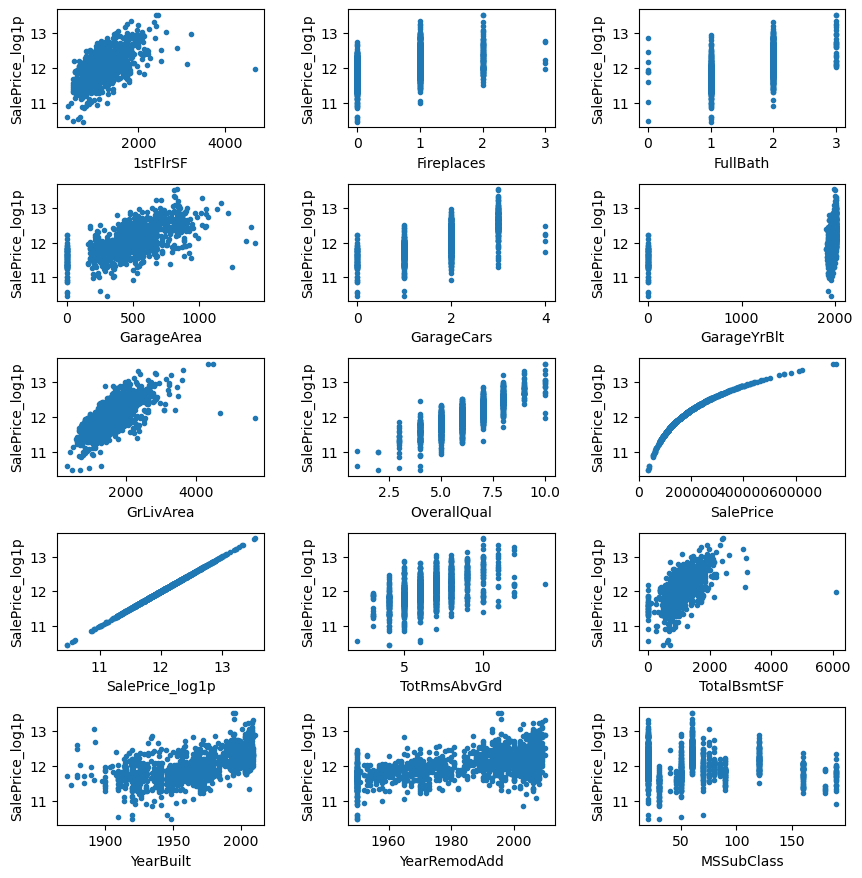

In [391]:
pp_feat = corr_features_target.tolist() + ["MSSubClass"]
print(pp_feat)
show_target_pairplot(df_data, pp_feat, LOGP_TARGET_COL)

# There are some outliers in 1stFlrSF, BuiltSF, GarageArea, GrLiveArea, TotalBsmtSF
# Fireplaces. 3 is not a common value. Test making it 2.
# What does fullbath == 0 means? Seems wrong value. Check.
# A lot of 0 in Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF
# YearBuilt and YearRemodAdd are kind of noicy. 
# MSSubClass seems to have some signal. Check ANoVA. There are some very low values (out of trend) for some categories.

## Checking main features distribution

38


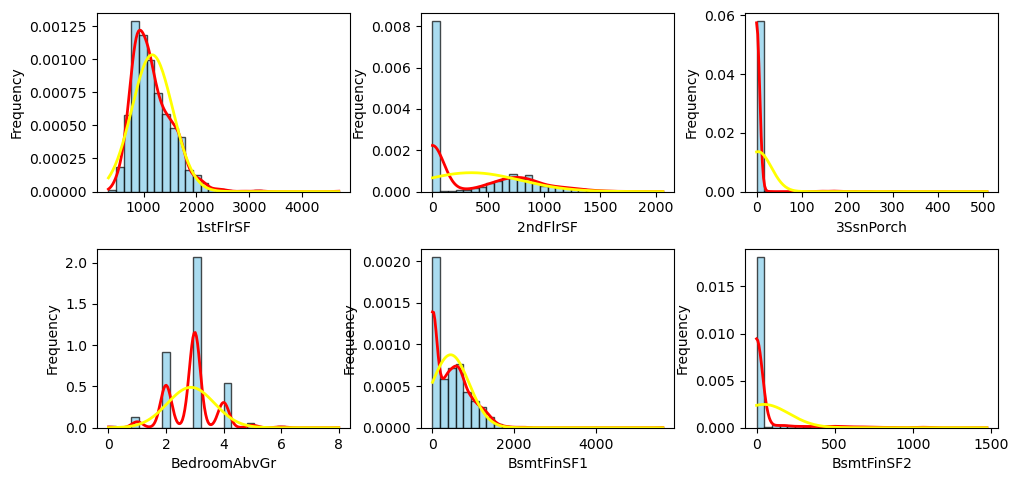

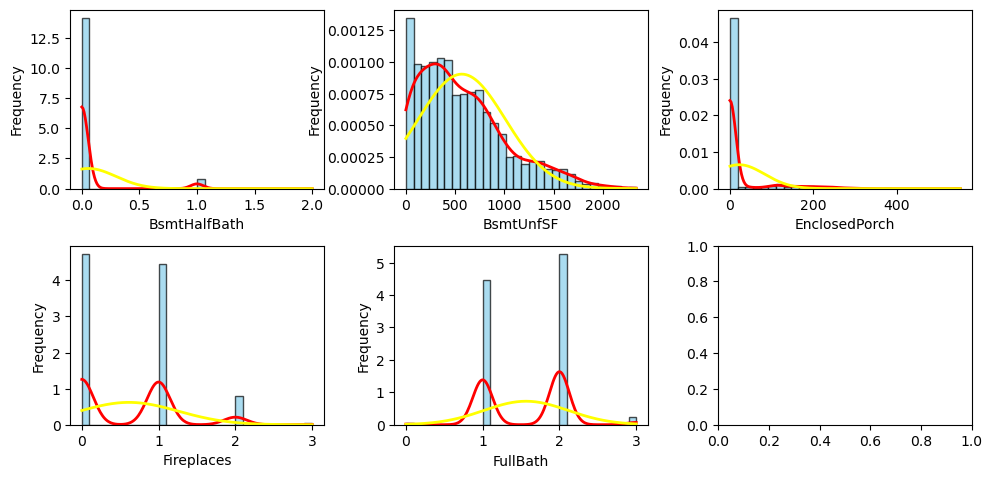

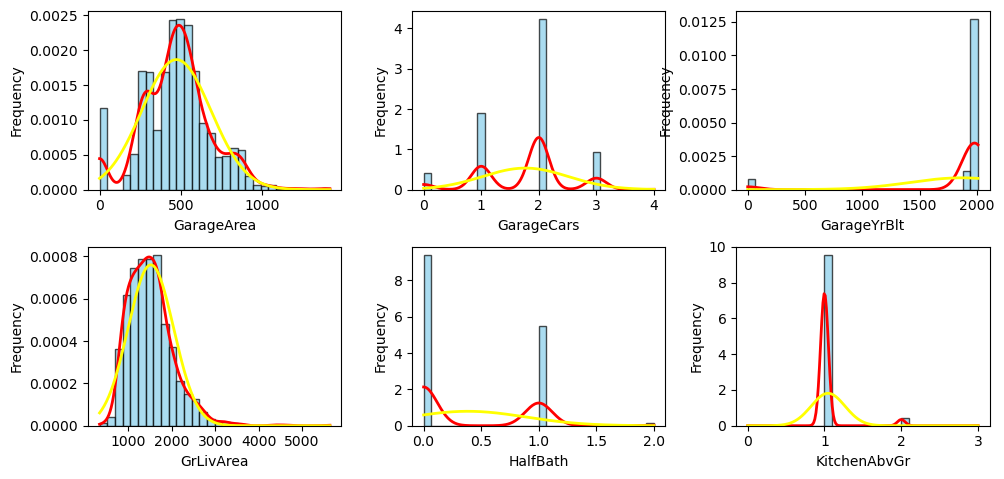

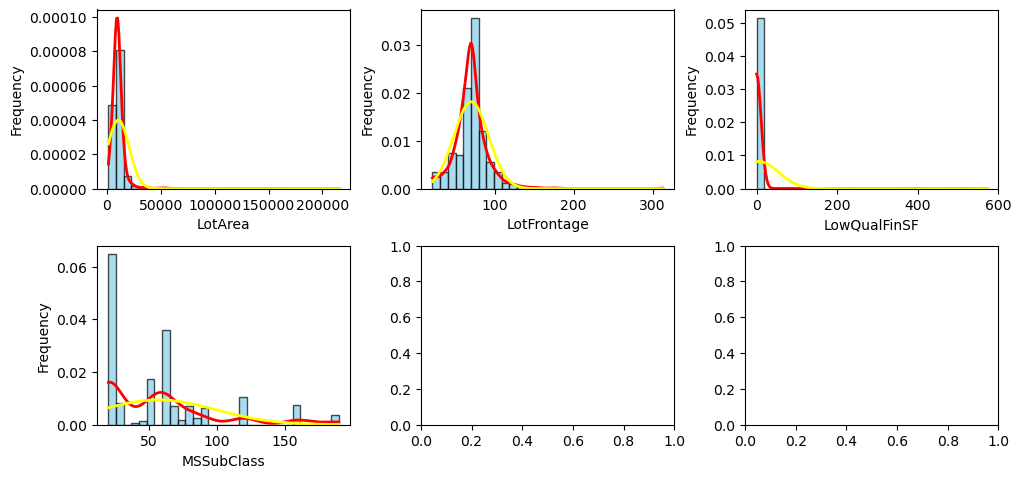

In [154]:
all_corr = np.unique(np.concatenate((corr_features_target, corr_features)))
print(len(all_corr))
show_distribution(df_data, all_corr[:6].tolist())
show_distribution(df_data, all_corr[7:12].tolist())
show_distribution(df_data, all_corr[12:18].tolist())
show_distribution(df_data, all_corr[18:22].tolist())

# Observations
# 1stFlrSF is heavy right skewed. Need to check outliers. Also it seems to have the same information than GrLivArea. Check removing or fixing the right skeew using log1p
# 2ndFlrSF is right skewed and it has a lot of 0. Suppose corresponds to houses not having 2nd floor. Maybe create a Has2ndFloor feature? Also check outliers.
# 3ssnPorch seems to be a constant  col. Check removal. If not, Has3SsnPorch?
# Same for EnclosedPorch
# GarageCars and GarageArea should provide the similar information. Try removing or using some combination. There are also several values = 0. Complement with field HasGarage 1/0
# There are a few samples having 3 bathrooms. Check if the related price. Consider creating a Has3Baths feature, or clipping value to 2.
# HalfBath mostly 0-1. Consider HasHalfBath
# Check 0 values in BedroomAbvGr
# BsmtFinSF1 has a lot of 0. Add HasBsmt 1/0. 
# BsmtFinSF2 Almost constant. Check
# BsmtHalfBath almost constant.
# Compare garage built with house built year. Check if has any signal.
# FullBath, a very few values > 2. Check signal. Consider adding HasFullBath
# KitchenAbvGr, a few values above 1. Almost constant, check signal.
# LotArea has 0 values? If yes, fix. Not possible data
# LowQualFinSF is almost constant. Check removal

### Categories

#### Functions

In [155]:
def print_cardinal_info(X, Y, feat):
  df_proc = X.join(Y)
  logpm = df_proc[LOGP_TARGET_COL].mean()
  res = {"val": [], "porc": [], "tg_mean": [], "var": [], "count": []}

  for val in  np.sort(df_proc[feat].unique()):
    df_val = df_proc[df_proc[feat] == val]
    porc =  df_val.shape[0] / df_proc.shape[0]
    tg_mean = df_val[LOGP_TARGET_COL].mean()
    var = df_val[LOGP_TARGET_COL].var()
    count = df_val.shape[0]

    res["val"].append(val)
    res["porc"].append(porc)
    res["tg_mean"].append(tg_mean)
    res["var"].append(var)
    res["count"].append(count)

  df_res = pd.DataFrame(res)
  print("Feature:", feat)
  println()
  for i, row in df_res.sort_values(by="tg_mean", ascending=False).iterrows():
    # copy values from row to variables
    val = row["val"]
    porc = row["porc"]
    tg_mean = row["tg_mean"]
    var = row["var"]
    count = row["count"]
    print(f"val: {val}", f"({pfmt(porc)}) - target mean: {nfmt(tg_mean)}", "var:", f"{nfmt(var)}", "count:", count)
  printspace()

#### Ordinal categories

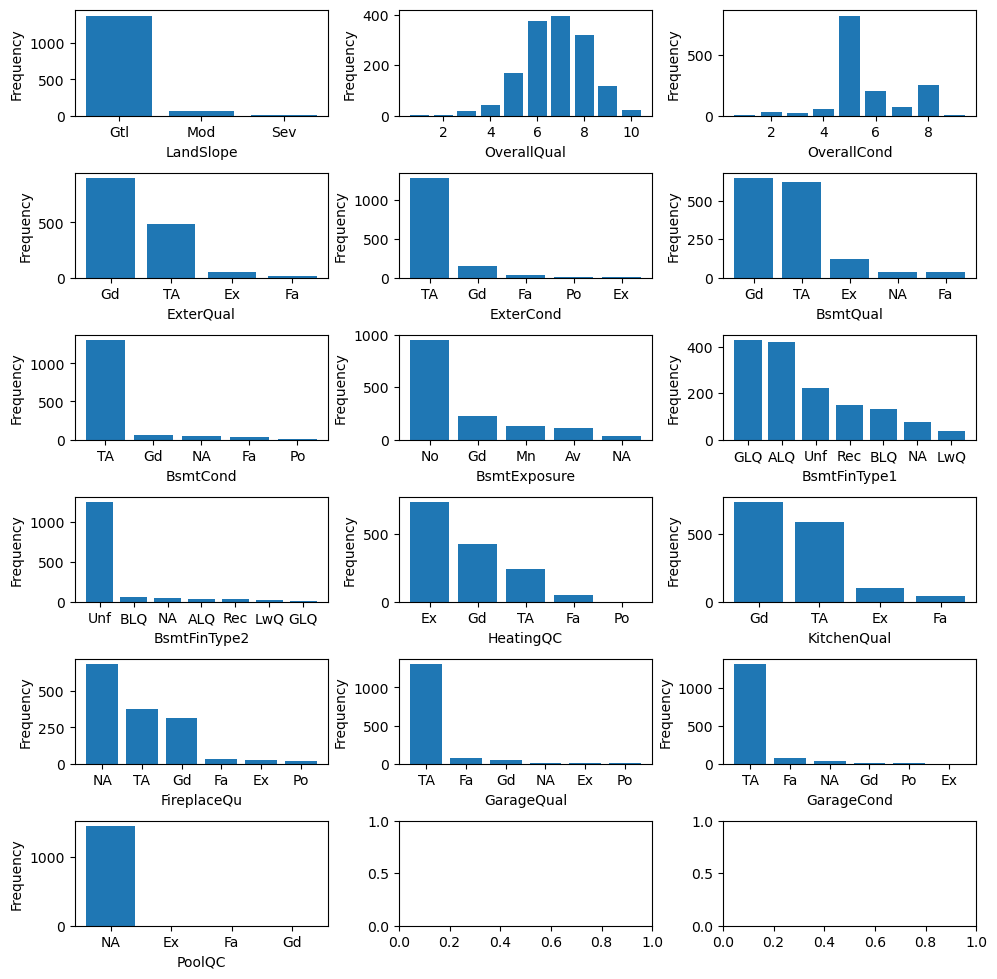

In [156]:
# Ordinal categories

#df_data[ORD_COLS].hist()
show_bar_plot(df_data, ORD_COLS)


# Observations
# LandSlope has 1 very dominant category. Maybe transform to IsLandSlopeGtl? Check signal
# OverallQual has a few low values. Check group in 3
# OverallCond, 5 is dominant and lower that 5 weard. Maybe create Low/Medium/Hight? 1/5/10 or something to maintain meaningful difference?
# ExterQual, Gd and TA are dominant. Low/Medium/Large could be applied here.
# ExterCond, same as ExterQual
# BsmtQual, Maybe here the values make more sense even having 2 dominant categories. Also NA means no basement. Should add HasBsmt field?
# BsmtCond, TA is extremelly dominant. Maybe is IsBsmtQualCondTypica and HasBsmt field?
# BsmtExposure, No (No exposure) is dominant, and other values exists. Try HasBsmtExposure field.
# BsmtFinType1, There are two dominant categories, but all off them have values. Keep as it is?
# BsmtFinType2, Unf (Unfinished) is very dominant. Check creating HasBsmtFinType2
# HeatingQC, Fa and Po has very low values. Test creating "Other" value or making Fa and Po = TA
# KitchenQual, leave as it is
# FireplaceQu, NA is dominant. Maybe create HasFireplace field and High/Medium/Low categories
# GarageQual, TA is dominant and has very few values different than that. Check removing the feature
# GarageCond, same than GarageQual
# PoolQC, NA is the 99% of the rows. Remove it. Just in case, check if the other 1% behaves very diffently in relation with the target. Create HasPool feature




In [157]:
# X = X.join(Y)
# show_target_pairplot(X, ["BalOverallQual"], LOGP_TARGET_COL)

#### Class Categories

In [158]:
def get_class_categories_feat(df):
    """
    Get class categories from the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data.
    
    Returns:
        list: List of class categories.
    """
    num_feat = df.select_dtypes(include=[np.number]).columns
    class_cat = [x for x in df.columns if x not in num_feat and x not in ORD_COLS]
    return class_cat
  
def print_class_cat_summary(df):
  for col in class_cat:
    println()
    print(df[col].value_counts())
    printspace()

def analyze_cat_dist(df, print_output=True):
  one_row_val_cols = []
  ext_imb_cols = []
  hei_imb_cols = []
  bin_cols = []
  const_cols = []
  tot = df.shape[0]
  for col in class_cat:
    vc = df[col].value_counts()
    data = {
      "value": vc.index,
      "count": vc.values 
    }
    df_vc = pd.DataFrame(data)
    PORC_COL = "porc"
    df_vc[PORC_COL] = df_vc["count"] * 100 / tot
    
    if df_vc[PORC_COL].max() > 99.0:
      const_cols.append(col)
    elif df_vc[PORC_COL].max() > 95.0:
      ext_imb_cols.append(col)
    elif df_vc[PORC_COL].max() > 70.0:
      hei_imb_cols.append(col)
    
    if vc.shape[0] < 3:
      bin_cols.append(col)

    if df_vc[df_vc["count"] == 1].shape[0] > 0:
      one_row_val_cols.append(col)

  if print_output:
    print("Extreamly imbalanced columns:")
    println()
    print(ext_imb_cols)
    printspace()
    print("Highly imbalanced columns:")
    println()
    print(hei_imb_cols)
    printspace()
    print("Binary columns:")
    println()
    print(bin_cols)
    printspace()
    print("Constant columns:")
    println()
    print(const_cols)
    printspace()
    print("Unique row columns:")
    println()
    print(one_row_val_cols)
  # Return categories to be analized deeply
  return one_row_val_cols, ext_imb_cols, hei_imb_cols, bin_cols, const_cols

In [159]:
class_cat = get_class_categories_feat(df_data) 
# print("Class categories")
# println()
# print(class_cat)

#print_class_cat_summary(df_data)

oner, extim, heim, bin, const = analyze_cat_dist(df_data)

Extreamly imbalanced columns:
------------------------------
['Condition2', 'RoofMatl', 'Heating', 'MiscFeature']
                              
Highly imbalanced columns:
------------------------------
['MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Condition1', 'BldgType', 'RoofStyle', 'CentralAir', 'Electrical', 'Functional', 'PavedDrive', 'Fence', 'SaleType', 'SaleCondition']
                              
Binary columns:
------------------------------
['Street', 'Utilities', 'CentralAir']
                              
Constant columns:
------------------------------
['Street', 'Utilities']
                              
Unique row columns:
------------------------------
['Utilities', 'Condition2', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Heating', 'Electrical', 'Functional', 'MiscFeature']


In [259]:

onerow, extim, heim, binc, const = analyze_cat_dist(df_data, print_output=False)
X = df_data.copy().drop(columns=LOGP_TARGET_COL)
Y = df_data[LOGP_TARGET_COL].copy()

# Rest of the columns
lowim = [x for x in class_cat if x not in (oner + extim + heim + binc + const)]
print("Other columns", lowim)

# for col in heim:
#      print_cardinal_info(X, Y, col)

def compute_mi(X, Y, feats, label):
  enc = LabelEncoder()
  X_enc = X[feats].copy()
  for col in feats:
    X_enc[f"enc_{col}"] = enc.fit_transform(X_enc[col])
  X_enc = X_enc.drop(columns=feats)
  mi = list(zip(feats, np.round(mutual_info_regression(X_enc, Y), 4)))
  df_mi = pd.DataFrame(mi, columns=["feature", "mi"]).sort_values(by="mi", ascending=False)
  df_mi["type"] = label 
  return df_mi 

df_mi = compute_mi(X, Y, extim, "extreme")
df_mi = pd.concat([df_mi, compute_mi(X, Y, heim, "high")])
df_mi = pd.concat([df_mi, compute_mi(X, Y, lowim, "low")])

df_mi = df_mi.sort_values(by="mi", ascending=False)
df_mi
#df_mi["feature"].tolist()



#show_target_pairplot(df_data, onerow, LOGP_TARGET_COL)
 
# X = df_data.copy().drop(columns=LOGP_TARGET_COL)
# Y = df_data[LOGP_TARGET_COL].copy()
#print_cardinal_info(X, Y, "Utilities")

# Observations:
# - Almost constant: Street, Utilities
# - Extreamelly imbalanced: MSZoning, Alley, LandCountour, Condition2, RoofMatl, Heating, CentralAir, PavedDrive
# - Highly imbalanced:  Condition1, BldgType, RoofStyle, Electrical, Functional, Fence, MiscFeature, SaleType
# - Imbolanced: LotShape, LotConfig, Neigbourhood, HouseStyle, Exterior1st, Exterior2nd, GarageType, SaleCondition
# - CentralAir is a binary category (S/N)
# - PavedDrive can be converted as a binary
# - Neigbourhood, Condition1 have values with a very few rows.
# - Condition2, RoffMat1 have values with only one row and also is extremely imbalanced
# - PaveDrive is not binary, but it can be converted to binary. It can be HasPaveDrive (1/0) instead of three values. Analyze values P and N
# - Street column is almost constant. It has only one row == NoSeWa. Even when Sale Price is different is not usable



Other columns ['LotShape', 'Neighborhood', 'HouseStyle', 'MasVnrType', 'Foundation', 'GarageType', 'GarageFinish']


,feature,mi,type
1,Neighborhood,0.5060,low
6,GarageFinish,0.2640,low
5,GarageType,0.2041,low
4,Foundation,0.1938,low
0,MSZoning,0.1271,high
3,MasVnrType,0.0909,low
0,LotShape,0.0891,low
2,HouseStyle,0.0848,low
13,SaleCondition,0.0758,high
12,SaleType,0.0696,high


## Outliers

### Analysis

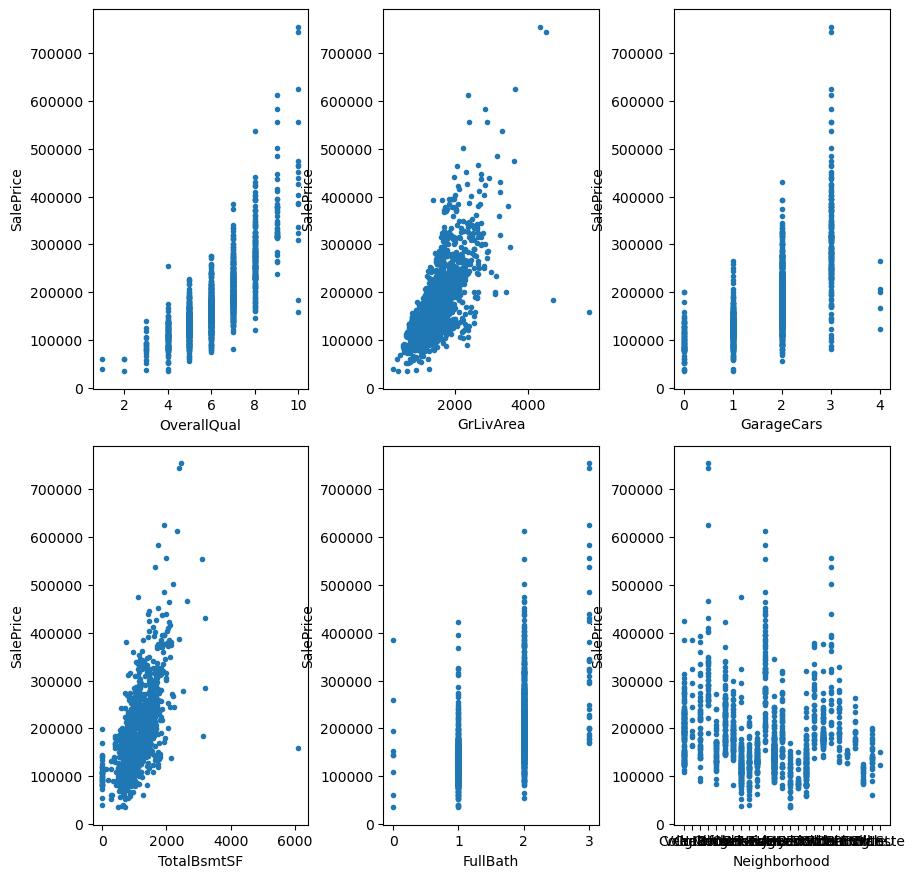

In [161]:
# From previous analysis
# Correlation ---------------
# OverallQual        0.790982
# GrLivArea          0.708624
# GarageCars         0.640409
# GarageArea         0.623431
# TotalBsmtSF        0.613581
# 1stFlrSF           0.605852
# FullBath           0.560664
# TotRmsAbvGrd       0.533723
# YearBuilt          0.522897
# YearRemodAdd       0.507101
# MI ------------------------
# neighbourhood      0.5059


plot_feat = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "Neighborhood"]
show_target_pairplot(df_data, plot_feat, TARGET_COL)


# Observations
# There are some very low SalePrice for a few houses with OverallQual == 10. 
# There a couple of suspicius low price houses having a very big GrLivAre. Maybe is an old house, the OveralQual or they are  the same having a high OverallQual and is a data error?
# A few houses having 4 carage cars and the price is very low. These values are not following the general trend.
# TotalBsmtSF has a similar shape than GrLivArea, but has an outlier with a lot of SF and a very low price. 
# There are two prices higher thant 700.000, corresponding to high standard features. However, the sd still is very high, it might worth trying winsorization.
# YearBuilt and YearRemodAdd are kind of noisy. 

### Functions

In [627]:
def get_iqr(df, feature):
  q1, q3 = df[feature].quantile([0.25, 0.75])
  iqr = q3 - q1
  return q1, q3, iqr

def get_iqr_bounds(q1, q3, iqr, interval=1.5):
    lower = q1 - interval * iqr
    upper = q3 + interval * iqr
    return lower, upper


def remove_outliers(df_rem, features, interval=1.5):
    df = df_rem.copy()
    updated = False
    for col in features:
        skew = df[col].skew()
        print(col, "Skew:", skew)
        if abs(skew) > 0.5:
            q1, q3, iqr = get_iqr(df, col)
            lower, upper = get_iqr_bounds(q1, q3, iqr, interval=interval)        
            print(col, "q1", q1, "q3: ", q3)
            print(col, "iqr", iqr, "lower: ", lower, "upper: ", upper)
            print("Outliers up: ", df[df[col] > upper][col].count())
            print("Outliers low: ", df[df[col] < lower][col].count())
    
            old_cnt = df.shape[0]
            df_rem = df[df[col] <= lower]
            df_rem = df[df[col] >= upper]
            df = df[df[col] > lower]
            df = df[df[col] < upper]
    
            print(old_cnt - df.shape[0], "Outliners Rows removed for col", col)
        if updated:
          print("New shape", df.shape)
          print(df_rem.shape[0]- df.shape[0], "Outliners Rows removed in total")
        else:
          print("No rows removed")
          df_rem = df_rem[~df_rem.index.isin(df.index)]
        return df, df_rem

### Tests

In [163]:
# Let try fixing the spoted values and plot again
df = df_data.copy()
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000))]
# Now the plots looks better
# GarageCars == 4 is not given usefull information, let's try to change it to 3 and see
df["GarageCars"] = df["GarageCars"].replace(4, 3)


# Let's try winorization with values over 99.5% quantile
if False:
  q = df["SalePrice"].quantile(0.99)
  print("Winsorization q:", q)
  df["SalePrice"] = df["SalePrice"].apply(lambda x: q if x > q else x)

# Capping by value
if True:
  df = df[df["SalePrice"] < 700000]
  
# NoRidge neighborhood outilers analysis
if False:
  # Neighborhood = NoRidge
  df[df["SalePrice"] > 700000]["Neighborhood"]
  print(df[df["Neighborhood"] == "NoRidge"]["SalePrice"].mean())
  print(df[df["Neighborhood"] == "NoRidge"]["SalePrice"].std())
  
  dfr = df[df["Neighborhood"] == "NoRidge"]
  dfr["zscore"] = dfr["SalePrice"].apply(lambda x: (x - dfr["SalePrice"].mean()) / dfr["SalePrice"].std())
  dfr[["SalePrice", "zscore"]].sort_values(by="SalePrice", ascending=False).head(10)

# Removing Outliers using IQR
if False:
  df, dfrem = remove_outliers(df, ["SalePrice"])

df.head()

#show_target_pairplot(df, plot_feat, TARGET_COL)
#show_target_pairplot(df, plot_feat, LOGP_TARGET_COL)
# Check new correlation
#df_corr_logp = df.corr(numeric_only=True)[np.abs(df.corr(numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
#print(df_corr_logp[LOGP_TARGET_COL])

# Observations
# Removing outliers based on GrLivArea also improves plots
# Clipping GaragetCars to 3 seems to make plots better
# Applying winsorization of 0.999 to SalePrice for very hight values makes the plots a little bit better. Same capping values > 700000
# Even using LOGP target, the high prices for NoRidge Neigborhood looks are souspicius
# Final shape applying IQR is good, but a lot of rows are removed
# Correlation has improved after this changes

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log1p,BuiltSF,BuiltRatio,NonBuiltSF
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,None,0,2,2008,WD,Normal,208500,12.247699,3114,2.713552,5336
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,None,0,5,2007,WD,Normal,181500,12.109016,2984,3.217158,6616
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,None,0,9,2008,WD,Normal,223500,12.317171,3314,3.394689,7936
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,None,0,2,2006,WD,Abnorml,140000,11.849405,3115,3.065811,6435
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,None,0,12,2008,WD,Normal,250000,12.429220,4179,3.412300,10081


# Processing

## Splitting data

In [326]:
def split_data(df, test_size=TEST_PORCENT, target_col=LOGP_TARGET_COL, original_target_col=TARGET_COL, random_state=RANDOM_STATE):
    df_train, df_test = train_test_split(
        df, 
        test_size=test_size, 
        random_state=random_state, 
        shuffle=True
    )
    Y = df_train.pop(target_col)
    Y_orig = df_train.pop(original_target_col)
    
    X = df_train
    Y_test = df_test.pop(target_col)
    X_test = df_test.drop(columns=original_target_col)   

    return X, Y, Y_orig, X_test, Y_test

def split_train_test_data():
  return g_X.copy(), g_Y.copy(), g_Y_orig.copy(), g_X_test.copy(), g_Y_test.copy()

# Using original data to avoid leaking
df_base_data = df_raw_data.copy()
# Transforming Target column
df_base_data[LOGP_TARGET_COL] = np.log1p(df_base_data[TARGET_COL])
# Removing SalePrice column and creating Splits
#df_base_data = df_base_data.drop(columns=[TARGET_COL], errors="raise")
g_X, g_Y, g_Y_orig, g_X_test, g_Y_test = split_data(df_base_data, test_size=TEST_PORCENT, random_state=RANDOM_STATE)

# Applying null fixed from EDA
g_X = fix_nulls(g_X)
g_X_test = fix_nulls(g_X_test)


Total null columns Before: 19
Total null columns After: 0
Total null columns Before: 18
Total null columns After: 0


## Categories

### Enconding Functions

In [172]:
# Encoding functions
def one_hot_encode(df_X, df_X_test):
    """
    One-hot encodes all columns in the given DataFrame using sklearn's OneHotEncoder.
    
    Args:
        df (pd.DataFrame): DataFrame containing only categorical columns to encode.
    
    Returns:
        pd.DataFrame: One-hot encoded DataFrame with new binary columns for each category.
    """
    # One-hot encode only low cardinality
    ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="infrequent_if_exist")  # drop first to avoid dummy trap
    ohe.fit(df_X)
    # Get feature names from encoder
    feature_names = ohe.get_feature_names_out(df_X.columns)

    # Convert back to DataFrames
    df_X_enc = pd.DataFrame(ohe.transform(df_X), columns=feature_names, index=df_X.index)
    df_X_test_enc = pd.DataFrame(ohe.transform(df_X_test), columns=feature_names, index=df_X_test.index)
    return df_X_enc, df_X_test_enc 


def ordinal_encode(df_X, df_X_test, ord_cat_maps):
    """
    Ordinally encodes specified columns in a DataFrame using provided category-to-integer mappings.
    
    Args:
        df (pd.DataFrame): DataFrame containing columns to encode.
        ord_cat_maps (dict): Dictionary mapping column names to their category-to-integer mappings.
    
    Returns:
        pd.DataFrame: DataFrame with ordinally encoded columns, prefixed with 'enc_'.
    """ 
    df_new = pd.DataFrame()
    df_new_test = pd.DataFrame()
    cols = df_X.columns
    for col in cols:
        if col in ord_cat_maps:
            df_new["enc_" + col] = df_X[col].apply(lambda x: my_map(x, col, ord_cat_maps))
            df_new_test["enc_" + col] = df_X_test[col].apply(lambda x: my_map(x, col, ord_cat_maps))

    return df_new, df_new_test

def target_encode(df_X, df_X_test, Y): 
    df_X_new = df_X.copy()
    df_X_test_new = df_X_test.copy()
    encoder = ce.TargetEncoder(cols=df_X.columns, smoothing=10).fit(df_X, Y)

    df_X_new = encoder.transform(df_X)
    df_X_new_test = encoder.transform(df_X_test)
    return df_X_new, df_X_new_test


def my_map(x, col, ord_cat_maps):
    values = ord_cat_maps.get(col, -1)
    val = values.get(x, -1)  # Default to -1 if x is not in the mapping
    if pd.isna(x):
        val = -1
    return val

In [289]:
def extract_categorical_columns(df, k=MAX_OHE_CARDINALITY):
    """
    Extracts numeric and categorical columns from a DataFrame, and splits categorical columns into low and high cardinality based on a threshold k.
    
    Args:
        df (pd.DataFrame): Input dataframe.
        k (int): Threshold for maximum unique values to consider a column low cardinality.
    
    Returns:
        num_cols (Index): Numeric columns.
        low_cardi (Index): Categorical columns with fewer than k unique values.
        high_cardi (Index): Categorical columns with k or more unique values.
    """
    # Not including category type because the data is loaded from a csv and 
    # the columns are not set to category type by default.
    cat_cols = df.select_dtypes(include=["str"]).columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    low_cardi = [col for col in cat_cols if df[col].nunique() < k] 
    high_cardi = [col for col in cat_cols if df[col].nunique() >= k]
    return num_cols, low_cardi, high_cardi


def get_cat_cols_df(df, ord_cols):
  df = df.copy().drop(columns=ord_cols, errors="ignore")
  return extract_categorical_columns(df, k=MAX_OHE_CARDINALITY)

def encode_categories(X, Y, X_test, Y_test, ord_cols, ord_cat_maps, target):
    """
    Encodes categorical columns in the DataFrame.
    
    Args:
        df_data (pd.DataFrame): DataFrame containing the data.
        ord_cols (list): List of ordinal columns to encode.
        target_feature (str): Name of the target feature column.
    
    Returns:
        X: Train pd.DataFrame with encoded categorical columns.
        X_test: Test pd.DataFrame with encoded categorical columns.
    """

    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    x_test = X_test.copy()
    # Removing unused columns
    X = X.drop(labels=[target, "Id"], axis=1, errors='ignore')
    X_test = X_test.drop(labels=[target, "Id"], axis=1, errors='ignore')

    # Selecting Categorical columns from low cardinality categories
    df_ord = X[ord_cols]
    df_data_no_ord = X.drop(labels=ord_cols, axis=1)

    df_ord_test = X_test[ord_cols]
    df_data_no_ord_test = X_test.drop(labels=ord_cols, axis=1)
  
    # Extracting numeric and categorical columns with low and high cardinality
    num_cols, low_cols, hi_cols = extract_categorical_columns(df_data_no_ord, k=MAX_OHE_CARDINALITY)

    subClassCol = "MSSubClass"
    # Training data
    df_cat = df_data_no_ord.drop(labels=num_cols, axis=1, errors='ignore').drop(labels=[subClassCol], axis=1, errors='ignore')
    df_num = X[num_cols].drop(labels=[subClassCol], axis=1, errors='ignore')
    
    #df_cat[subClassCol] = df_num.pop(subClassCol)
    df_hi_cat = df_cat[hi_cols]
    df_low_cat = df_cat.drop(labels=hi_cols, axis=1, errors='ignore')

    #Testing data
    df_cat_test = df_data_no_ord_test.drop(labels=num_cols, axis=1, errors='ignore').drop(labels=[subClassCol], axis=1, errors='ignore')
    df_num_test = X_test[num_cols].drop(labels=[subClassCol], axis=1, errors='ignore')

    #df_cat_test[subClassCol] = df_num_test.pop(subClassCol)
    df_hi_cat_test = df_cat_test[hi_cols]
    df_low_cat_test = df_cat_test.drop(labels=hi_cols, axis=1, errors='ignore')
    
    # One-hot encoding low cardinality categorical columns
    df_mscclass, df_mscclass_test = one_hot_encode(X[[subClassCol]], X_test[[subClassCol]])
    df_low_cat, df_low_cat_test = one_hot_encode(df_low_cat, df_low_cat_test)
    df_ord_cat, df_ord_cat_test = ordinal_encode(df_ord, df_ord_test, ord_cat_maps)
    
    # Target encoding high cardinality categorical columns
    df_target_cat, df_target_cat_test = target_encode(df_hi_cat, df_hi_cat_test, Y) 
    
    X = pd.concat([df_num, df_ord_cat, df_low_cat, df_target_cat, df_mscclass], axis=1)
    X_test = pd.concat([df_num_test, df_ord_cat_test, df_low_cat_test, df_target_cat_test, df_mscclass_test], axis=1)
  
    return X, X_test

# Experiment

## Baseline

In [167]:
# For baseline, category columns will be enconded without any transformation or processing to get an initial idea of performance 

run_label = "baseline"

X, Y, _, X_test, Y_test = split_train_test_data()
X, X_test = encode_categories(
    X, Y, X_test, Y_test, 
    ord_cols=ORD_COLS, 
    ord_cat_maps=ORD_COLS_VALUES, 
    target=LOGP_TARGET_COL
)


print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label, clear_scores=True, desc="Basic category enconding. No data transformation. No feature engineering")

#show_global_scores()
#plot_scores()
show_scores_stats()

X: 80 X_test: 80
X: 197 X_test: 197
Train dataset shape: (1168, 197)
Test dataset shape: (292, 197)


/tmp/ipykernel_888/2288531615.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns
/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


                              
Last Run: 1 - baseline
------------------------------
Model: LiRe CV_MEAN: 0.1461 TRN_NRMSE: 0.0007
Model: TrRe CV_MEAN: 0.2179 TRN_NRMSE: 0.0000
Model: Rig CV_MEAN: 0.1400 TRN_NRMSE: 0.0007
Model: XBReg CV_MEAN: 0.1489 TRN_NRMSE: 0.0001
Description: Basic category enconding. No data transformation. No feature engineering
                              
Score Stats
------------------------------
Name: baseline
Avg Tr: 0.0003
Avg CV: 0.1632
Best(CV): [baseline] (1) Rig --> Score: 0.1400 Proc.Time: 0.0702 secs
Description:
Basic category enconding. No data transformation. No feature engineering
                              
Top 5
------------------------------
baseline(1) - Rig --> CV_MEAN: 0.1400, delta: nan, proc.time: 0.0702 secs
baseline(1) - LiRe --> CV_MEAN: 0.1461, delta: 0.0060, proc.time: 0.9363 secs
baseline(1) - XBReg --> CV_MEAN: 0.1489, delta: 0.0028, proc.time: 45.4563 secs
baseline(1) - TrRe --> CV_MEAN: 0.2179, delta: 0.0690, proc.time: 0.19

## Engineering

### Functions

In [168]:
### Functions

def drop_cols(X, X_test, cols):
  X = X.drop(labels=cols, axis=1, errors="raise")
  X_test = X_test.drop(labels=cols, axis=1, errors="raise")
  return X, X_test

def get_ord_cols(by="used", used=[], removed=[], ord_cols=ORD_COLS):
  return get_cols(by=by, used=used, removed=removed, all_cols=ord_cols)
  
def get_cat_cols(by="used", used=[], removed=[], cat_cols=[]):
  return get_cols(by=by, used=used, removed=removed, all_cols=cat_cols)
  
def get_cols(by="used", used=[], removed=[], all_cols=[]):
  cols_to_remove = removed.copy()
  cols_to_use = used.copy()
  if by == "used": 
    cols_to_remove = [x for x in all_cols if x not in used] 
  elif by == "removed":
    cols_to_use = [x for x in all_cols if x not in removed]
  else:
    raise ValueError("by must be 'used' or 'removed'")

  return cols_to_use, cols_to_remove

In [ ]:
X, Y, Y_orig, X_test, Y_test = get_train_test_data()

# Compacting some OverallQual values to create a more balanced distribution

old_feat = "ExterCond"
new_feat = "BalExterCond"
# for xs in [X, X_test]:
#   xs["BalExterCond"] = np.where((xs["ExterCond"] == "Ex") | (xs["ExterCond"] == "Gd") | (xs["ExterCond"] == "TA"), 1, 0)
   # xs[new_feat] = np.where(xs[old_feat] == 6, 2, xs[new_feat])
   # xs[new_feat] = np.where(xs[old_feat] > 6, 3, xs[new_feat])

print("train")
print_cardinal_info(X, Y, old_feat)
print("test")
print_cardinal_info(X_test, Y_test, old_feat)
# print("new feat")
# print_cardinal_info(X, Y, new_feat)
 
# The following columns didn"t affect the validation score, regardless of whether they were compacted, transformed, or left unchanged.
#ord_cols_to_drop = ORD_COLS 
# cols_to_drop = ["LandSlope", "OverallQual", "OverallCond", "ExterQual", "ExterCond", \
#                  "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", \
#                   "GarageQual", "GarageCond", \
# #                 "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", \
#                 "PoolQC"]



#X[X["YearBuilt"] <= 1941][["HeatingQC"]].join(Y).groupby("HeatingQC").mean().sort_values(by=LOGP_TARGET_COL, ascending=False)
X[X["ExterCond"] == "Po"]



### Process Description

##### Notes
**23/02/26**
- Plotting residuals for Ridge, it shows that resituals are bigger for low prices.
- Dividing residuals in 5 quantiles we can confirm that:
    - (10.632, 11.714]    0.093581
    - (11.714, 11.894]    0.064025
    - (11.894, 12.082]    0.057325
    - (12.082, 12.301]    0.060717
    - (12.301, 12.746]    0.063642


**20/02/26**
- Creating new fields improve performance in TreeModels and mostly XBRegressor. Simple linear regression has also improved a bit.

**19/02/26**
- Creating binary fields for columns having a lot of zero values doesn't improve the performance.
- 
**16/02/26**
- Outliers
  - Removing GrLivArea > 4000 and SalePrice < 200000 improves the score.
  - Removing GarageCars == 4 and changing it to 3 improves the score a little bit, but removed anyway to fit the general trend.
  - Removing rows by using IQR on SalePrice improved the score a bit. Maintaining for now, but a lot of rows are removed.
  - Capping SalePrice > 500000 makes the performance slightly better. But it is still better using IQR (SalePrice).
  - Capping SalePrice > 700000 and 600000 makes the performance decrease
  - Applying winsorization doesn't improve the score. (Tryied with 0.95 and 0.99 quantiles)
  - Using IQR in log1p SalePrice doesn't remove rows. 
- 
**14/02/26**
- Removing all extreme imbalanced categories degrades the score.
- MSZoning has a lot of signal.
- By running using one non ordinal category features at a time, and using the ones that degrade the performance less, the score improves. These features are not the same than the list created ordering by MI. 
- Removing all non ordinal categories results in a degradation in the score. So, there is some signal lost there.

**07/02/26**
- Running all ordinal categories without any transformation one at a time  results in only HeatingHC, ExterQual, ExternCond performing better than baseline.
- Adding HeatingHC, ExterQual, ExternCond without transformations to ordinal cols used and removing all others improved performnance.
- For HeatingHQ, there is one only value ="Po". Also, there are no values in test set. The row was removed and the performance continuous equal.
- ExterQual is unbalanced but it does not have a clear way to collapse categories that improves performance. Leaving as it is.
- ExterCond is unbalanced. Created a 1/0 feature and doesn't improve performance. There was only one row having value="Po" and it was removed. Performance is a little worse than using the field as it is.
- For now will leave categories using HeatingQC, ExterQual and ExternCond and continue playing with other aspects 

**06/02/26**
- Baseline is 0.1400
- After fixing some issue in **encode_categories** function, removing all ordinal columns is now a little bit worse than baseline (0.1408). Starting again analisis.
- Adding only LandSlope the score goes up to 0.1412
 
**05/02/26**
- By removing all ordinal categories the score has reduced more than 0.01. Let's play with them to see if we can improve the score by adding one by one, with or without transformatios.
- Removing all ordinals cols and adding HasPool doesn't have impact in CV
- Adding PoolQC the score goes up. => it's a noisy feature that has to be removed. Adding HasPool Feat doesn't change the score. Perhaps PoolArea is enough for pool information.

### Run

In [823]:
"""
Preprocessing
"""

def preproces_data():
  """
    Working with Categories
  """
  X, Y, Y_orig, X_test, Y_test = split_train_test_data()
  
  X["CentralAirNum"] = X["CentralAir"].apply(lambda x: 1 if x == "Y" else 0)
  X = X.drop(columns=["CentralAir"], errors="raise")
  
  # Getting class categories features 
  num_cols, low_cardi, high_cardi = get_cat_cols_df(X, ORD_COLS)
  class_cat_cols = low_cardi + high_cardi 
  
  # Best Score class categories
  class_cat_cols_used = ["Neighborhood", "MSZoning", "Functional", "Condition2", 'SaleCondition', 'Exterior1st', 'GarageType', 
   'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', "MiscFeature", "RoofMatl", 'Fence', 
  'Condition1', 'BldgType', 'GarageFinish', 'Foundation'] # Street, and Utilities removed (almost constant) 
  
  # Features ordered from best performance to worst when running one by one
  # ['Neighborhood', 'Functional', 'CentralAir', 'Condition2', 'SaleCondition', 'Street', 'Exterior1st', 'GarageType', 
   # 'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', 'MiscFeature', 'RoofMatl', 'Fence', 'Utilities', 
  # 'Condition1', 'BldgType', 'GarageFinish', 'Foundation', 'Heating', 'HouseStyle', 'LandContour', 'Electrical', 'RoofStyle', 'Exterior2nd']
  
  # Getting class categories to removed from train data
  class_cat_cols_used , class_cat_cols_to_drop = get_cat_cols(by="used", used=class_cat_cols_used, removed=[], cat_cols=class_cat_cols)
  
  # Get a copy of original data to avoid leaking
  X, Y, Y_orig, X_test, Y_test = split_train_test_data()
  
  # There is only one row with HeatingQC=Po, so removing it to avoid statistical issues
  X = X[~X.index.isin([325, 250])]
  Y = Y[~Y.index.isin([325, 250])]
  
  """
   Processing ordinal columns 
  """
  ord_cols_eng = []
  ord_cols_used = ["ExterQual", "HeatingQC", "ExterCond", "GarageQual"]
  ord_cols_used.extend(ord_cols_eng)
  ord_cols_to_drop = [] 
  proc_ord_cols=ORD_COLS.copy()
  proc_ord_cols.extend(ord_cols_eng)
  ord_cols_used, ord_cols_to_drop = get_ord_cols(by="used", used=ord_cols_used, removed=ord_cols_to_drop, ord_cols=proc_ord_cols)
  
  """
   Removing not used class and oridinal features 
  """
  X, X_test = drop_cols(X, X_test, class_cat_cols_to_drop)
  X, X_test = drop_cols(X, X_test, ord_cols_to_drop)
  
  """
    run_label: Groups several experiments related to an aspect (categories, outliers, new features, etc) to then identify the best score obtained
  """
  run_label = "proc_outliers"
  # Description of the current experiment
  exp_desc = "- Processing categories. Merging values and creating 1/0 features\n"
  exp_desc+= f"- Using Ordinal categories => {ord_cols_used} . Removing the only row having HeatingQC=Po and ExterCond=Po\n"
  exp_desc+= f"- Using NO ordinal categories => {cat_cols_used}\n"
  exp_desc+= "- Removed Street and Utilities features because they are almost constant\n"
  
  """ 
  Processing categories
  - One hot encoding for low cardinality class categories
  -  Ordinal encoding for ordinal categories
  - Target encoding for "Neigborhood"
  """
  X, X_test = encode_categories(
      X, Y, X_test, Y_test, 
      ord_cols=ord_cols_used,
      ord_cat_maps=ORD_COLS_VALUES, 
      target=LOGP_TARGET_COL
  )
    
  """
   Working with outliers
  """
  # Removing big houses having very low price out of the general trend
  glArea = 4000
  target_val = 200000
  print(f"Removing GrLiveArea > {glArea} and target < {target_val}") 
  df_out = X.copy().join(Y_orig)
  df_idx = df_out[(df_out["GrLivArea"] > glArea) & (df_out[TARGET_COL] < target_val)].index
  X = X[~X.index.isin(df_idx)]
  Y = Y[~Y.index.isin(df_idx)]
  Y_orig = Y_orig[~Y_orig.index.isin(df_idx)]
  
  # GarageCars == 4 is not given usefull information, let's try to change it to 3 and see
  X["GarageCars"] = X["GarageCars"].replace(4, 3)
  
  # Removing outliers using IQR on SalePrice
  _, dfrem = remove_outliers(X.copy().join(Y_orig), ["SalePrice"])
  X = X[~X.index.isin(dfrem.index)]
  Y = Y[~Y.index.isin(dfrem.index)]
  Y_orig = Y_orig[~Y_orig.index.isin(dfrem.index)]
  
  
  """
   Outliers description
  """
  exp_desc+= "- Removed hight 'GrLivArea' and low SalePrice outilers. \n"
  exp_desc+= "- Replacing GarageCargs = 4 by 3\n"
  #exp_desc+= "- Removig outliers using IQR (Log1p SalePrice)\n"
  #exp_desc+= "- \n"
  
  """
   Feature Engineering
  """
  run_label = "feat_engineering_combination"
  
  # There are only 3 values of fireplace == 3
  X["Fireplaces"] = X["Fireplaces"].replace(3, 2)
  
  #FlullBath == 0 are only 6. Also, some of them have HalfBath == 0. Seems like it is an error.
  X["FullBath"] =  X["FullBath"].apply(lambda x: 1 if x == 0 else x) 
 
  # # Using X_new only to make documentation easy
  # # Adding new features
  X_new = pd.DataFrame(index=X.index)
  X_new["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"] + X["GarageArea"] + X["PoolArea"]
  X_new["TotalSFTimesOverallQual"] =  X_new["TotalSF"] * X["OverallQual"]
  X_new["GarageAreaTimesQual"] = X["GarageArea"] * X["enc_GarageQual"]
  X_new["HouseAge"] = this_year() - X["YearBuilt"] 
  X_new["BathGrLivArea"] = X["FullBath"] + X["HalfBath"]
  X_new["BathBsmt"] = X["BsmtFullBath"] + X["BsmtHalfBath"]
  X_new["Bath"] = X["FullBath"] + X["HalfBath"] +  X["BsmtFullBath"] + X["BsmtHalfBath"]
  X_new["GrLivAreaOverRoom"] = X["GrLivArea"] / (X["TotRmsAbvGrd"] + 1)
  X_new["GrLivAreaOverBedroom"] = X["GrLivArea"] / (X["BedroomAbvGr"] + 1)
  X_new["GrLivAreaOverBath"] =  X["GrLivArea"] / (X_new["BathGrLivArea"] + 1)
  X_new["TotalBsmtSFOverBath"] =  X["TotalBsmtSF"] / (X_new["BathBsmt"] + 1)
  X_new["GarageAreaOverCar"] = X["GarageArea"] / (X["GarageCars"] + 1)
  X = X.join(X_new)
  
  # Adding binary fields
  zero_cols = ["GarageArea", "TotalBsmtSF", "2ndFlrSF", "PoolArea"]
  for c in zero_cols:
    X[f"Has{c}"] = X[c].apply(lambda x: 0 if x == 0 else 1) 
  
  exp_desc+= f"- Added combination columns: {X_new.columns.tolist()} \n"
  exp_desc+= f"- Adding binaary fields: {zero_cols}\n"
  #exp_desc+= "\n"
  
  # Dropping cols
  # 3SsnPorch is almost constant and there is no signal in relation with the target
  X = X.drop(columns=["3SsnPorch"])
  
  """
   Transformations description
  """
  exp_desc+= "- Fixed Fireplaces and fullbath.\n"
  exp_desc+= "- FROM RUN_ID = 141 Using KFolds to validate. ==> Score goes UP\n"
  exp_desc+= "- \n"
  return X, Y, desc

X, Y, desc = preproces_data()
#eval_models(X, Y, X_test, Y_test, label=run_label, clear_scores=False, desc=exp_desc, save_score=True)


"""
 Stats 
"""
#show_scores_stats()







/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [5, 7, 12, 17] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Removing GrLiveArea > 4000 and target < 200000
SalePrice Skew: 1.7521877475550638
SalePrice q1 130000.0 q3:  215000.0
SalePrice iqr 85000.0 lower:  2500.0 upper:  342500.0
Outliers up:  45
Outliers low:  0
45 Outliners Rows removed for col SalePrice
No rows removed
age null shape (0, 12)
xnew nulls Index([], dtype='str')
x nulls Index([], dtype='str')
alphas [1.00000000e-04 1.20450354e-04 1.45082878e-04 1.74752840e-04
 2.10490414e-04 2.53536449e-04 3.05385551e-04 3.67837977e-04
 4.43062146e-04 5.33669923e-04 6.42807312e-04 7.74263683e-04
 9.32603347e-04 1.12332403e-03 1.35304777e-03 1.62975083e-03
 1.96304065e-03 2.36448941e-03 2.84803587e-03 3.43046929e-03
 4.13201240e-03 4.97702356e-03 5.99484250e-03 7.22080902e-03
 8.69749003e-03 1.04761575e-02 1.26185688e-02 1.51991108e-02
 1.83073828e-02 2.20513074e-02 2.65608778e-02 3.19926714e-02
 3.85352859e-02 4.64158883e-02 5.59081018e-02 6.73415066e-02
 8.11130831e-02 9.77009957e-02 1.17681195e-01 1.41747416e-01
 1.70735265e-01 2.05651231e-0

'\n Stats \n'

# Modeling

## Ridge

In [ ]:
X, Y, _ = preproces_data()

cv = KFold(
      n_splits=5,
      shuffle=True,
      random_state=RANDOM_STATE
    )
alphas = np.logspace(-4, 4, 100)
rig = Ridge()
grid = GridSearchCV(
  rig,
  {"alpha": alphas },
  cv=cv,
  scoring="neg_root_mean_squared_error",
  n_jobs=-1
)
grid.fit(X, Y)

print("Best alpha:", grid.best_params_)
print("Best CV:", -grid.best_score_)

## XGBRegressor

In [ ]:
X, Y, _ = preproces_data()

cv = KFold(
      n_splits=5,
      shuffle=True,
      random_state=RANDOM_STATE
    )
alphas = np.logspace(-4, 4, 100)
rig = Ridge()
grid = GridSearchCV(
  rig,
  {"alpha": alphas },
  cv=cv,
  scoring="neg_root_mean_squared_error",
  n_jobs=-1
)
grid.fit(X, Y)

print("Best alpha:", grid.best_params_)
print("Best CV:", -grid.best_score_)

# Analysis

## Residuals (Ridge)

In [ ]:
# rig = Ridge(alpha=0.7)
# preds = rig.fit(X, Y).predict(X)
# residuals =  Y - preds
# plt.scatter(preds, residuals, alpha=0.5)
# plt.axhline(0, color='red')
# plt.xlabel("Predicted")
# plt.ylabel("Resisuals")
# plt.show()


# df_res = pd.DataFrame({
#     "pred": preds,
#     "residual": residuals
# })

# df_res["abs_res"] = np.abs(df_res["residual"])
# df_res["bin"] = pd.qcut(df_res["pred"], 5)

# print(df_res.groupby("bin")["abs_res"].mean())

In [603]:
# ['1stFlrSF', 'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars', 'GarageYrBlt', 'GrLivArea', 'OverallQual', 
# 'TotRmsAbvGrd', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'MSSubClass']

# Notes from EDA
# There are some outliers in 1stFlrSF, BuiltSF, GarageArea, GrLiveArea, TotalBsmtSF
# Fireplaces. 3 is not a common value. Test making it 2.
# What does fullbath == 0 means? Seems wrong value. Check.
# A lot of 0 in Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF
# YearBuilt and YearRemodAdd are kind of noicy. 
# MSSubClass seems to have some signal. Check ANoVA. There are some very low values (out of trend) for some categories.
# Observations
# 1stFlrSF is heavy right skewed. Need to check outliers. Also it seems to have the same information than GrLivArea. Check removing or fixing the right skeew using log1p
# 2ndFlrSF is right skewed and it has a lot of 0. Suppose corresponds to houses not having 2nd floor. Maybe create a Has2ndFloor feature? Also check outliers.
# 3ssnPorch seems to be a constant  col. Check removal. If not, Has3SsnPorch?
# Same for EnclosedPorch
# GarageCars and GarageArea should provide the similar information. Try removing or using some combination. There are also several values = 0. Complement with field HasGarage 1/0
# There are a few samples having 3 bathrooms. Check if the related price. Consider creating a Has3Baths feature, or clipping value to 2.
# HalfBath mostly 0-1. Consider HasHalfBath
# Check 0 values in BedroomAbvGr
# BsmtFinSF1 has a lot of 0. Add HasBsmt 1/0. 
# BsmtFinSF2 Almost constant. Check
# BsmtHalfBath almost constant.
# Compare garage built with house built year. Check if has any signal.
# FullBath, a very few values > 2. Check signal. Consider adding HasFullBath
# KitchenAbvGr, a few values above 1. Almost constant, check signal.
# LotArea has 0 values? If yes, fix. Not possible data
# LowQualFinSF is almost constant. Check removal

def plot_grouped_mean(col):
  X, Y, Y_orig,  X_test, Y_test = split_train_test_data()
  df_eng =  X.copy().join(Y_orig)
  df_eng = df_eng.groupby(col).agg({
      #TARGET_COL: "mean",
      TARGET_COL: "count",
      #TARGET_COL: "mean",
  }).sort_values(by=TARGET_COL, ascending=False)
  #df_eng.plot(kind="bar")
  print(df_eng)

#plot_grouped_mean("Fireplaces")
#f_regression(X[["MSSubClass"]], Y, center=True)
#print_cardinal_info(X, Y, "3SsnPorch")


X, Y, Y_orig,  X_test, Y_test = split_train_test_data()
zero_cols = ["Fireplaces", "GarageArea", "GarageCars", "YearRemodAdd", "TotalBsmtSF", "2ndFlrSF", "EnclosedPorch", "BsmtFinSF2"]

cons_cols = ["3SsnPorch", "2ndFlrSF", "EnclosedPorch", "BsmtFinSF2"]
#for c in (zero_cols + cons_cols):
for c in ["HalfBath"]:
  #print_cardinal_info(X, Y, c)
  row_count = X.shape[0]
  unique_count = X[c].unique().shape[0]
  zero_count = X[X[c] == 0][c].shape[0]
  print(c, unique_count, "diff values")
  print(c, zero_count, "rows with 0 (", nfmt(zero_count / row_count * 100), "%)")
  new_col = f"Has{c}"
  X[new_col] = X[c].apply(lambda x: 0 if x == 0 else 1)
  print_cardinal_info(X, Y, new_col)
  printspace()

# Convert the fields in the column below in a list
# Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF


X["HalfBath"].value_counts()

X.columns


HalfBath 3 diff values
HalfBath 725 rows with 0 ( 62.0719 %)
Feature: HasHalfBath
------------------------------
val: 1.0 (37.93%) - target mean: 12.1882 var: 0.1286 count: 443.0
val: 0.0 (62.07%) - target mean: 11.9227 var: 0.1552 count: 725.0
                              
                              


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# Residual analysis

# Stats

In [791]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

g_df_scores.loc[g_df_scores["failed"].isnull()] 
#show_global_scores()
#plot_scores()
#show_scores_stats()
#g_df_scores[g_df_scores["model"] == "XBReg"]
g_df_scores[["run_id", "model", "run_label", "CV_MEAN", "DESC"]].sort_values(by="CV_MEAN", ascending=True)
#g_df_scores[["run_id", "failed", "model", "run_label", "CV_MEAN", "DESC"]].sort_values(by="run_id", ascending=False)

# g_df_scores[g_df_scores["failed"] == False].groupby("run_id").agg({
#     "CV_MEAN": "mean",
#     "TRN_RMSE": "mean",
# }).sort_values(by="CV_MEAN", ascending=True)


# myscore = g_df_scores[g_df_scores["failed"] == False][["run_id", "model", "run_label", "CV_MEAN", "DESC", "date", "failed"]].sort_values(by="CV_MEAN", ascending=True)
# myscore[(myscore["run_id"] < 33) & (myscore["run_id"] > 9) & (myscore["model"] == "Rig")].head(30)
# pattern = r"col\s+'([^']+)'"

# Extracting column names from the DESC field ordered by score asc
# matches = myscore["DESC"].str.extractall(pattern)[0].unique().tolist()
# print(matches)
#show(g_df_scores)
#g_df_scores.
# c = ["Neighborhood", "MSZoning", "Functional", "CentralAir", "SaleCondition"]
# c1 = ["Condition2", "Street", "Exterior1st", "GarageType"]

#"BsmtFinSF2", "

#g_df_scores[g_df_scores["run_id"] > 135][["run_id", "model", "CV_MEAN", "validation_tag"]].sort_values(by="run_id", ascending=False)
g_df_scores.loc[g_df_scores["run_id"] == 139, "validation_tag"] = "cross_val_score"
# g_df_scores["validation_tag"]

# Removing Stats

In [584]:
g_df_scores[g_df_scores["run_id"] > 96].sort_values(by="run_id", ascending=False)

# for i in range(98, 105):
#   mark_failed_score(i)
#mark_failed_score(82)

,run_id,date,model,run_label,TRN_RMSE,TRN_NRMSE,TRN_PERC_NRMSE,TST_RMSE,TST_NRMSE,TST_PERC_NRMSE,CV_MEAN,CV_01,CV_02,CV_03,CV_04,CV_05,DESC,EVAL_TIME_SEC,failed
359,102,2026-02-19 11:29,XBReg,feat_engineering,0.00729,0.00061,0.06081,0,0,0,0.14505,0.11845,0.16453,0.16596,0.13666,0.13966,"- Processing categories. Merging values and creating 1/0 features\n- Using Ordinal categories => ['ExterQual', 'HeatingQC', 'ExterCond'] . Removing the only row having HeatingQC=Po and ExterCond=Po\n- Using NO ordinal categories => ['Neighborhood', 'MSZoning', 'Functional', 'CentralAir', 'Condition2', 'SaleCondition', 'Exterior1st', 'GarageType', 'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', 'MiscFeature', 'RoofMatl', 'Fence', 'Condition1', 'BldgType', 'GarageFinish', 'Foundation']\n- Removed Street and Utilities features because they are almost constant\n- Removed hight 'GrLivArea' and low SalePrice outilers. \n- Replacing GarageCargs = 4 by 3\n- Removig outliers using IQR (Log1p SalePrice)\n- \n- Binary features for columns having a lot of zero values: ['BsmtFinSF2', 'GarageArea', '2ndFlrSF', 'EnclosedPorch', 'TotalBsmtSF']\n\n- Fixed Fireplaces and fullbath.\n- \n",43.510191,True
358,102,2026-02-19 11:28,Rig,feat_engineering,0.10728,0.00895,0.89492,0,0,0,0.12537,0.11234,0.14158,0.14404,0.11962,0.10926,"- Processing categories. Merging values and creating 1/0 features\n- Using Ordinal categories => ['ExterQual', 'HeatingQC', 'ExterCond'] . Removing the only row having HeatingQC=Po and ExterCond=Po\n- Using NO ordinal categories => ['Neighborhood', 'MSZoning', 'Functional', 'CentralAir', 'Condition2', 'SaleCondition', 'Exterior1st', 'GarageType', 'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', 'MiscFeature', 'RoofMatl', 'Fence', 'Condition1', 'BldgType', 'GarageFinish', 'Foundation']\n- Removed Street and Utilities features because they are almost constant\n- Removed hight 'GrLivArea' and low SalePrice outilers. \n- Replacing GarageCargs = 4 by 3\n- Removig outliers using IQR (Log1p SalePrice)\n- \n- Binary features for columns having a lot of zero values: ['BsmtFinSF2', 'GarageArea', '2ndFlrSF', 'EnclosedPorch', 'TotalBsmtSF']\n\n- Fixed Fireplaces and fullbath.\n- \n",0.033390,True
357,102,2026-02-19 11:28,TrRe,feat_engineering,0.00121,0.00010,0.01008,0,0,0,0.21774,0.19536,0.23686,0.22379,0.21628,0.21641,"- Processing categories. Merging values and creating 1/0 features\n- Using Ordinal categories => ['ExterQual', 'HeatingQC', 'ExterCond'] . Removing the only row having HeatingQC=Po and ExterCond=Po\n- Using NO ordinal categories => ['Neighborhood', 'MSZoning', 'Functional', 'CentralAir', 'Condition2', 'SaleCondition', 'Exterior1st', 'GarageType', 'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', 'MiscFeature', 'RoofMatl', 'Fence', 'Condition1', 'BldgType', 'GarageFinish', 'Foundation']\n- Removed Street and Utilities features because they are almost constant\n- Removed hight 'GrLivArea' and low SalePrice outilers. \n- Replacing GarageCargs = 4 by 3\n- Removig outliers using IQR (Log1p SalePrice)\n- \n- Binary features for columns having a lot of zero values: ['BsmtFinSF2', 'GarageArea', '2ndFlrSF', 'EnclosedPorch', 'TotalBsmtSF']\n\n- Fixed Fireplaces and fullbath.\n- \n",0.177592,True
356,102,2026-02-19 11:28,LiRe,feat_engineering,0.10558,0.00881,0.88079,0,0,0,0.12850,0.11982,0.14652,0.14131,0.12194,0.11290,"- Processing categories. Merging values and creating 1/0 features\n- Using Ordinal categories => ['ExterQual', 'HeatingQC', 'ExterCond'] . Removing the only row having HeatingQC=Po and ExterCond=Po\n- Using NO ordinal categories => ['Neighborhood', 'MSZoning', 'Functional', 'CentralAir', 'Condition2', 'SaleCondition', 'Exterior1st', 'GarageType', 'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', 'MiscFeature', 'RoofMatl', 'Fence', 'Condition1', 'BldgType', 'GarageFinish', 'Foundation']\n- Removed Street and Utilities features because t

# Checks

In [565]:
import re

def extract_bin_info_from_results(df):
  # Assuming your DataFrame is named df
  # Filter rows containing the target phrase
  df = df[df["failed"] == False]
  mask = df['DESC'].str.contains('Checking binary one by one', regex=False)
  filtered = df[mask]

  print("Found:", len(filtered))
  features = []
  mean_values = []
  models = []
  
  reg = re.compile("Checking binary one by one. Added (\\w+)")
  for row in filtered.iterrows():
    field_name = ""
    field_name = ""
    cv_mean = 0
    row = row[1]
    model = row['model']
    desc_text = row['DESC']
    # Extract field_name using regex
    #match = re.search(r'Added Has(\w+) from (\w+)', desc_text)
    #print(desc_text)
    matches = list(reg.finditer(desc_text))
    #print("m:", matches)
    #println()
    if len(matches) > 0:
      field_name = matches[-1].group(0).split()[-1]
      cv_mean = row['CV_MEAN']

    if field_name != "":
      #r = {"feature": field_name, "CV_MEAN": cv_mean}
      features.append(field_name)
      mean_values.append(cv_mean)
      models.append(model)
    #print("Field name:", field_name, "CV_MEAN", cv_mean)
  df_res = pd.DataFrame({
      "model": models,
      "feature": features,
      "CV_MEAN": mean_values
  })
  print(df_res.sort_values(by="CV_MEAN")["feature"]) 

extract_bin_info_from_results(g_df_scores)


Found: 32
30       HasBsmtFinSF2
6        HasGarageArea
14     HasYearRemodAdd
10       HasGarageCars
18      HasTotalBsmtSF
2        HasFireplaces
22         Has2ndFlrSF
26    HasEnclosedPorch
28       HasBsmtFinSF2
8        HasGarageCars
4        HasGarageArea
12     HasYearRemodAdd
24    HasEnclosedPorch
0        HasFireplaces
16      HasTotalBsmtSF
20         Has2ndFlrSF
19      HasTotalBsmtSF
31       HasBsmtFinSF2
23         Has2ndFlrSF
27    HasEnclosedPorch
7        HasGarageArea
3        HasFireplaces
11       HasGarageCars
15     HasYearRemodAdd
21         Has2ndFlrSF
5        HasGarageArea
9        HasGarageCars
25    HasEnclosedPorch
1        HasFireplaces
17      HasTotalBsmtSF
29       HasBsmtFinSF2
13     HasYearRemodAdd
Name: feature, dtype: str
